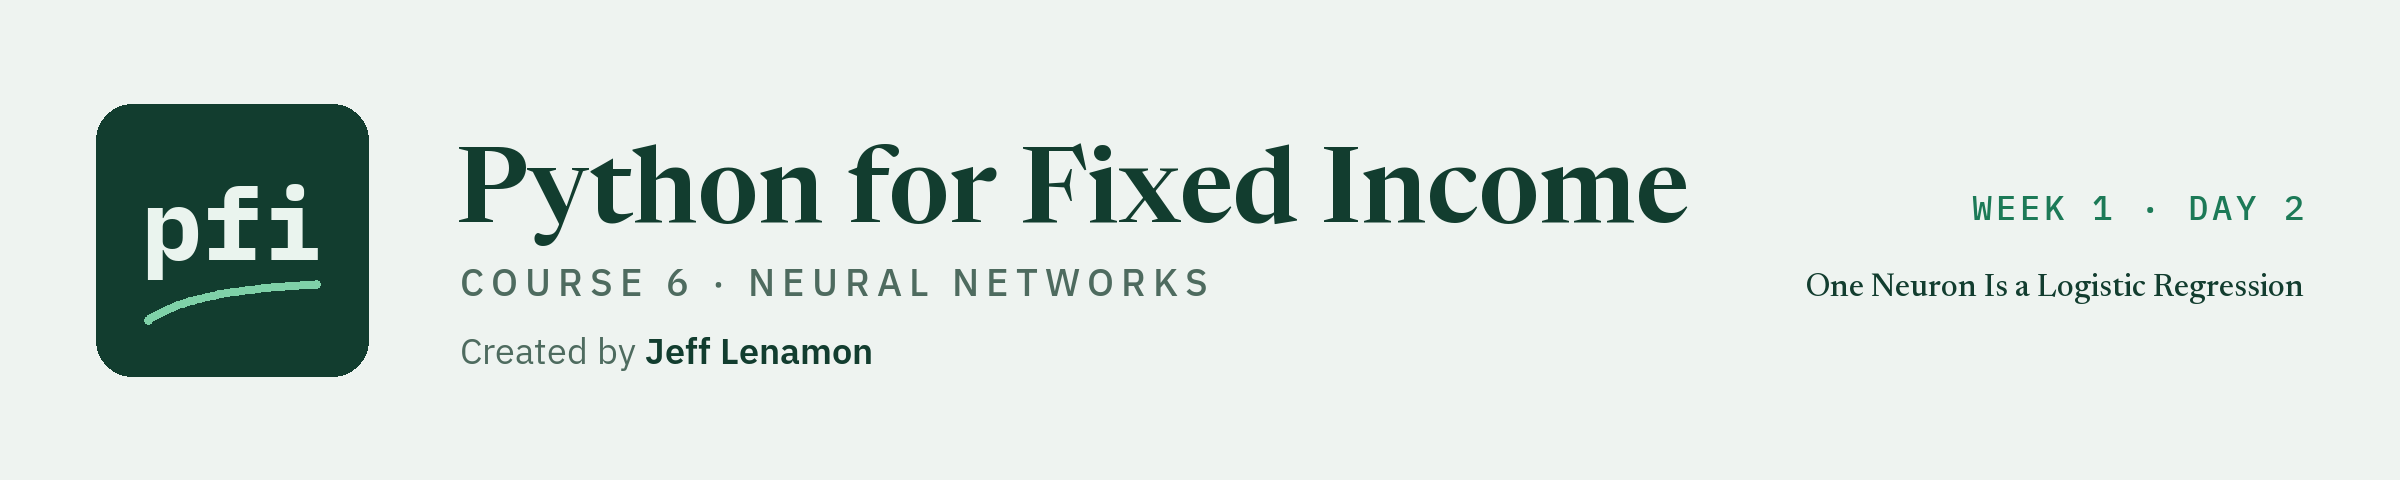

# One Neuron Is a Logistic Regression

Week 1, Day 2. Day 1 fitted one neuron by hand and found Course 4's logistic regression. Today the same neuron is built and fitted in Keras, first on two columns and then on all 19, and its weights are checked against scikit-learn's and Excel's Solver.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course6_neural_networks/week1/day2/02_one_neuron_is_a_logistic_regression.ipynb)

Day 1 ended with one step: a Keras neuron and `gradient_step` landed on the same weights. Today Keras does the whole fit. The claim in the title is exact: **a network of one sigmoid neuron, fitted to the mean log loss, is a logistic regression**, so its weights must equal scikit-learn's, and Course 4 day 6's odds ratios must come back. You check that on two columns, then on all 19, where something new shows up: columns that are nearly copies of each other, whose weights can move a long way while the loss hardly changes.

**The card rules, as on every card day in this course.**

* **The data is real.** `credit_card_default.csv` is the UCI file of 30,000 credit card accounts in Taiwan in 2005, which Courses 4 and 5 modelled. Consumer credit there differs from US credit, and nothing here describes any other market.
* **People's attributes are never features.** `SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` are never used, and no output is grouped by them. Every model uses the other 19 columns, Course 4's.
* **Course 4's split, rebuilt, and the test-row rule.** Course 4's 6,000 test rows stay closed, as day 1 section 1.2 set out. From today the 18,000 training rows are split once more: 14,400 to fit and a stratified fifth, 3,600 rows, to stop or choose on. The 6,000 validation rows report once per chosen model.
* **A model's output is described, never acted on.** A network's output is the model probability of default in this file, or a flag at a threshold; a network fitted with class weights gives the model's score. No output of either kind is a credit decision for any person.

Today you will:

1. See that a Keras `Dense` layer of one unit with a sigmoid is day 1's formula.
2. Carve the fit and stopping rows, and scale for a network with `fit_arrays`, fitted on the fit rows only.
3. Take `compile` and `fit` apart, argument by argument.
4. Fit the neuron on two columns and read its weights with `neuron_coefficients`: scikit-learn's weights and Course 4's odds ratios.
5. Find the same weights with Solver in Excel.
6. Fit the neuron on all 19 scaled columns, and see why near-copy columns make single weights hard to read.
7. See a mini-batch fit stop short of the minimum, and choose between the two on the stopping rows.
8. Score the chosen neuron once on the validation rows.

Q. Set up today's work folder: the same setup cell as day 1, then the modules as day 1 left them.

In [1]:
# today's setup: the TensorFlow and thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# TensorFlow writes start-up notices to stderr: these three lines must run before TensorFlow is imported
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, TensorFlow, or LightGBM is imported: if you ran another
# cell first, restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("tensorflow", "tensorflow"), ("keras", "keras"), ("lightgbm", "lightgbm"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd
import tensorflow as tf
import keras

# one thread for TensorFlow too, set before TensorFlow runs anything
tf.config.threading.set_intra_op_parallelism_threads(1)
tf.config.threading.set_inter_op_parallelism_threads(1)
# TensorFlow's own Python notices are turned down to errors; on Windows the one it writes is that it has no GPU
# support there (day 1 explains it)
tf.get_logger().setLevel("ERROR")
# where TensorFlow has a deterministic version of an operation, use it
tf.config.experimental.enable_op_determinism()

# the versions the saved outputs of this notebook came from (course6_neural_networks/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "scipy": "1.18.1", "tensorflow": "2.21.0", "keras": "3.15.1", "lightgbm": "4.7.0", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42
# Keras's seed sets Python's, numpy's, and TensorFlow's random generators at once
keras.utils.set_random_seed(SEED)

# the kinds of device TensorFlow can use on this machine
devices = sorted({device.device_type for device in tf.config.list_physical_devices()})
print(f"Devices TensorFlow can use: {', '.join(devices)}")

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "credit_card_default.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course6_02_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, scipy 1.18.1, tensorflow 2.21.0, keras 3.15.1, lightgbm 4.7.0, matplotlib 3.11.2, pytest 9.1.1
Devices TensorFlow can use: CPU
Work folder: pfi_course6_02_6cicsqzt, in your temp folder
Data files from the data folder of the course repo: credit_card_default.csv
SEED = 42


Q. Write `mlkit.py`, Course 4's complete module, and `ensemblekit.py`, Course 5's complete module, both unchanged. `netkit` imports them.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


In [3]:
%%writefile ensemblekit.py
"""ensemblekit: the pieces of ensembles, tuning, and rare-event modelling that the libraries leave to the analyst,
written down and tested.

Written day by day in Python for Fixed Income, Course 5: Advanced Machine Learning. It imports mlkit (Course 4's
module) and never changes it.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 5 never scores a row that Course 4 used as a test row. The course4_*_rows functions rebuild Course 4's
  splits exactly and return only the rows Course 5 may use; the closed rows are never returned.
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart.
- Every library call that can use more than one thread is given n_jobs=1, so every run gives the same digits.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from sklearn.model_selection import train_test_split  # Course 4's split, rebuilt

import mlkit  # Course 4's module: thresholds, metrics, splitters, and the no-leak check

# the card file: its outcome column and the 19 model columns (the four person columns are never features)
CARD_TARGET = "default payment next month"
CARD_FEATURES = ["LIMIT_BAL", "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"] + \
    [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)]


def course4_card_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    """Course 4's 60/20/20 split of the card file, rebuilt, without its test rows.

    Input: frame, the 30,000 accounts of credit_card_default.csv as read by pd.read_csv.
    Output: X_train (18,000 rows), X_valid (6,000 rows), y_train, y_valid, with the 19 model columns in
    CARD_FEATURES and the file's row labels. Course 4's 6,000 test rows are never returned.
    Convention: the same two calls as Course 4: train_test_split(test_size=0.2, stratify=y, random_state=42), then
    the remaining 80 percent split with test_size=0.25, stratified, same seed. The validation rows were used in
    Course 4 to choose a threshold and a pruning level, never to fit.
    Raises ValueError if a column is missing or the frame does not have 30,000 rows.
    """
    # check the frame is the whole card file
    missing = [name for name in CARD_FEATURES + [CARD_TARGET] if name not in frame.columns]
    if missing:
        raise ValueError(f"frame lacks the columns {missing}")
    if len(frame) != 30_000:
        raise ValueError(f"frame must hold the 30,000 card accounts, not {len(frame)}")
    X, y = frame[CARD_FEATURES], frame[CARD_TARGET]
    # Course 4's first cut puts 20 percent aside as test rows: they are dropped here, never returned
    X_rest, _, y_rest, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    # Course 4's second cut: a quarter of the rest (20 percent of the file) as validation rows
    X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest,
                                                          random_state=42)
    mlkit.assert_disjoint(X_train.index, X_valid.index)
    return X_train, X_valid, y_train, y_valid


def bootstrap_positions(n_rows: int, seed: int = 42) -> np.ndarray:
    """Draw n_rows row positions with replacement: one bootstrap sample.

    Input: n_rows, how many rows the data has (at least 1); seed, the random seed.
    Output: an array of n_rows positions from 0 to n_rows - 1, in the order drawn. A position can appear more than
    once, and some positions do not appear at all (about 36.8 percent of them for large n_rows).
    Convention: np.random.default_rng(seed).integers(0, n_rows, n_rows), so the same seed gives the same sample.
    Excel: =RANDBETWEEN(1,n) draws one position but takes no seed and changes at every recalculation.
    Raises ValueError if n_rows is below 1.
    """
    if n_rows < 1:
        raise ValueError(f"n_rows must be at least 1, not {n_rows}")
    # one generator per call, seeded, so the draw does not depend on anything drawn before
    rng = np.random.default_rng(seed)
    return rng.integers(0, n_rows, n_rows)


def out_of_bag(n_rows: int, drawn: np.ndarray) -> np.ndarray:
    """The positions a bootstrap sample never drew: its out-of-bag rows.

    Inputs: n_rows, how many rows the data has; drawn, the positions of a bootstrap sample.
    Output: the sorted positions from 0 to n_rows - 1 that are not in drawn.
    Convention: a model fitted on the drawn rows has never seen these rows, so they can score it.
    Raises ValueError if drawn is empty or holds a position outside 0 to n_rows - 1.
    """
    positions = np.asarray(drawn)
    if positions.size == 0:
        raise ValueError("drawn is empty")
    if positions.min() < 0 or positions.max() > n_rows - 1:
        raise ValueError(f"drawn holds a position outside 0 to {n_rows - 1}")
    # every position, minus the ones drawn at least once
    return np.setdiff1d(np.arange(n_rows), positions)


from sklearn.metrics import roc_auc_score  # ranking quality from probabilities


def bagged_proba(bagging, X: pd.DataFrame) -> np.ndarray:
    """Bagging by hand: the average of each fitted tree's class-1 probability, each on its own columns.

    Inputs: bagging, a fitted BaggingClassifier; X, the rows to score, with the columns it was fitted on.
    Output: one number per row, the mean over bagging.estimators_ of each tree's class-1 probability on the
    columns listed in bagging.estimators_features_. It equals bagging.predict_proba(X)[:, 1] within 1e-12.
    Convention: a tree whose bootstrap sample held only one class gives 0 for class 1 when that class is 0.
    Excel: with each tree's column of outputs pasted side by side, =AVERAGE(B2:K2) filled down.
    Raises ValueError if bagging is not fitted.
    """
    if not hasattr(bagging, "estimators_"):
        raise ValueError("bagging is not fitted: call fit first")
    # the trees were fitted on plain arrays of the chosen columns, so score them the same way
    values = np.asarray(X, dtype=float)
    total = np.zeros(len(values))
    for tree, columns in zip(bagging.estimators_, bagging.estimators_features_):
        proba = tree.predict_proba(values[:, columns])
        # the tree's classes are positions in bagging.classes_; class 1 is position 1
        position = np.flatnonzero(tree.classes_ == 1)
        total += proba[:, position[0]] if position.size else 0.0
    return total / len(bagging.estimators_)


def oob_auc(model, y_train) -> float:
    """ROC AUC of the out-of-bag probabilities of a bagged model or a random forest.

    Inputs: model, fitted with oob_score=True on the training rows; y_train, those rows' outcomes, in order.
    Output: roc_auc_score(y_train, model.oob_decision_function_[:, 1]): each row scored only by the trees that
    did not draw it.
    Convention: model.oob_score_ is the accuracy of the out-of-bag votes for a classifier, not ROC AUC; this
    function gives the ranking number the course compares models by.
    Raises ValueError if the model was fitted without oob_score=True, or if a row has no out-of-bag vote (too few
    trees, so some row was drawn by every tree).
    """
    if not hasattr(model, "oob_decision_function_"):
        raise ValueError("the model has no out-of-bag outputs: fit it with oob_score=True")
    proba = model.oob_decision_function_[:, 1]
    if np.isnan(proba).any():
        raise ValueError(f"{int(np.isnan(proba).sum())} rows have no out-of-bag vote: use more trees")
    return float(roc_auc_score(y_train, proba))


def tree_correlation(forest, X: pd.DataFrame) -> float:
    """How much the trees of an ensemble agree: the mean pairwise correlation of their class-1 outputs.

    Inputs: forest, a fitted random forest, extra-trees, or bagging model (anything with estimators_, and
    estimators_features_ for bagging); X, the rows to score (validation rows).
    Output: the mean of the upper triangle of np.corrcoef over the trees' class-1 probabilities on X: 1 means
    every tree gives the same ranking, 0 means no linear agreement.
    Convention: averaging trees removes less noise the more they agree; a random forest tries a random subset of
    columns at each split to lower this number.
    Excel: =CORREL(B2:B6001,C2:C6001) for one pair of pasted tree columns.
    Raises ValueError if the ensemble has fewer than two trees.
    """
    trees = list(forest.estimators_)
    if len(trees) < 2:
        raise ValueError(f"need at least two trees, the ensemble has {len(trees)}")
    # each tree was fitted on a plain array; bagging may give each tree its own columns
    values = np.asarray(X, dtype=float)
    columns = getattr(forest, "estimators_features_", [slice(None)] * len(trees))
    outputs = np.array([tree.predict_proba(values[:, cols])[:, -1] for tree, cols in zip(trees, columns)])
    # the correlation of every pair of trees, then the mean above the diagonal
    matrix = np.corrcoef(outputs)
    return float(matrix[np.triu_indices(len(trees), k=1)].mean())


from sklearn.inspection import permutation_importance  # the drop in a score when one column is shuffled


def importance_table(model, X_valid: pd.DataFrame, y_valid, scoring: str = "roc_auc", n_repeats: int = 5,
                     seed: int = 42) -> pd.DataFrame:
    """Two importance measures side by side: impurity importance and permutation importance.

    Inputs: model, a fitted tree ensemble with feature_importances_, fitted on a DataFrame; X_valid, y_valid,
    rows the model was NOT fitted on (validation rows); scoring, the score whose drop is measured; n_repeats, how
    many shuffles per column; seed, the random seed of the shuffles.
    Output: a DataFrame indexed by feature with columns impurity (model.feature_importances_, from the training
    rows, sums to 1), permutation (the mean drop in the score over n_repeats shuffles of that column),
    permutation_sd (their standard deviation), impurity_rank and permutation_rank (1 = largest), sorted by
    permutation, largest first.
    Convention: impurity importance is learned on the training rows and rewards columns the trees could split on
    to fit noise; permutation importance on unseen rows measures how much the score leans on a column there.
    Neither measure is a cause. permutation_importance runs with n_jobs=1.
    Raises ValueError if the model has no feature_importances_ (an unfitted model, or a linear model).
    """
    if not hasattr(model, "feature_importances_"):
        raise ValueError("the model has no feature_importances_: fit a tree ensemble first")
    # shuffle each column n_repeats times on the rows given and record the drop in the score
    result = permutation_importance(model, X_valid, y_valid, scoring=scoring, n_repeats=n_repeats,
                                    random_state=seed, n_jobs=1)
    table = pd.DataFrame({"impurity": model.feature_importances_, "permutation": result.importances_mean,
                          "permutation_sd": result.importances_std}, index=pd.Index(X_valid.columns, name="feature"))
    # rank 1 is the largest value; ties share the better rank
    table["impurity_rank"] = table["impurity"].rank(ascending=False, method="min").astype(int)
    table["permutation_rank"] = table["permutation"].rank(ascending=False, method="min").astype(int)
    return table.sort_values("permutation", ascending=False, kind="stable")


from sklearn.model_selection import cross_val_predict  # out-of-fold outputs, one per row


def course4_bench_rows(bench: pd.DataFrame, ratings: pd.DataFrame) -> pd.DataFrame:
    """Course 4's 615 training bonds of the synthetic benchmark, without its 206 test bonds.

    Inputs: bench, the 821 bonds of benchmark.csv; ratings, ratings.csv (rating and score).
    Output: the 615 training bonds with every column of bench plus score (the rating's number, 1 = AAA),
    log_oas (natural log of oas in bp), years (days from as_of_date to maturity / 365.25), and amount_bn
    (amount_outstanding in billions), with bench's row labels. Course 4's 206 test bonds are never returned.
    Convention: Course 4's split, train_test_split(test_size=0.25, random_state=42) on the joined rows. The bonds
    and their spreads are invented by the course's generator.
    Raises ValueError if bench does not hold 821 bonds.
    """
    if len(bench) != 821:
        raise ValueError(f"bench must hold the 821 benchmark bonds, not {len(bench)}")
    # the rating's number, joined row for row (each rating appears once in ratings)
    frame = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    frame["log_oas"] = np.log(frame["oas"])
    dates = pd.to_datetime(frame["maturity"]) - pd.to_datetime(frame["as_of_date"])
    frame["years"] = dates.dt.days / 365.25
    frame["amount_bn"] = frame["amount_outstanding"] / 1e9
    # Course 4's split: the second part was its test set, dropped here
    train, _ = train_test_split(frame, test_size=0.25, random_state=42)
    return train


def oof_threshold(model, X, y, target_recall: float = 0.70, cv=None) -> tuple[float, np.ndarray]:
    """The course's threshold rule, applied to out-of-fold probabilities on the training rows.

    Inputs: model, an unfitted (or fitted) classifier with predict_proba; X, y, the training rows; target_recall,
    the share of defaults to catch; cv, a splitter (default mlkit.cv_folds(), stratified 5-fold, seed 42).
    Output: (threshold, proba): proba holds each training row's class-1 probability from the fold model that did
    not see it (cross_val_predict, n_jobs=1); threshold is mlkit.threshold_for_recall(y, proba, target_recall),
    the highest threshold whose out-of-fold recall is at least target_recall.
    Convention: the threshold is chosen on training rows only, so validation and test rows stay for reporting.
    cross_val_predict fits clones, so the caller's model is left as it was.
    Raises ValueError from mlkit.threshold_for_recall on a bad target or no row of class 1.
    """
    folds = cv if cv is not None else mlkit.cv_folds()
    proba = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
    return mlkit.threshold_for_recall(y, proba, target_recall), proba


def samme_alpha(weighted_error: float, learning_rate: float = 1.0) -> float:
    """The weight AdaBoost gives one stump's vote, for two classes.

    Inputs: weighted_error, the stump's error with each row counted by its weight (above 0, below 0.5);
    learning_rate, the shrinkage AdaBoostClassifier applies (default 1.0).
    Output: learning_rate * ln((1 - e) / e), in natural logs. A stump right on 80 percent of the weight gets
    ln(4) = 1.3863; one barely better than a coin gets almost 0.
    Convention: the SAMME weight with two classes (its extra term ln(classes - 1) is ln 1 = 0); it equals
    AdaBoostClassifier's estimator_weights_.
    Excel: =LN((1-e)/e).
    Raises ValueError unless 0 < weighted_error < 0.5.
    """
    if not 0 < weighted_error < 0.5:
        raise ValueError(f"weighted_error must be above 0 and below 0.5, not {weighted_error}")
    return float(learning_rate * np.log((1 - weighted_error) / weighted_error))


def reweight(weights: np.ndarray, missed: np.ndarray, alpha: float) -> np.ndarray:
    """AdaBoost's new row weights after one round: the rows the stump missed count for more.

    Inputs: weights, the current row weights (non-negative); missed, 1 where the stump was wrong and 0 where it
    was right, the same length; alpha, the stump's weight (samme_alpha).
    Output: weights * exp(alpha * missed), divided by their sum so the new weights sum to 1.
    Excel: =w*EXP(alpha*miss) filled down, then each divided by the column's SUM.
    Raises ValueError if the lengths differ, the input is empty, or a weight is negative.
    """
    w = np.asarray(weights, dtype=float)
    m = np.asarray(missed, dtype=float)
    if w.size == 0 or w.shape != m.shape:
        raise ValueError(f"weights and missed must be non-empty and the same length, not {w.size} and {m.size}")
    if (w < 0).any():
        raise ValueError("weights must not be negative")
    # a missed row is multiplied by e^alpha, a correct row by 1
    new = w * np.exp(alpha * m)
    return new / new.sum()


from sklearn.tree import DecisionTreeRegressor  # one round's tree, fitted to the residuals


def boost_by_hand(X, y, n_rounds: int, learning_rate: float, max_depth: int, seed: int = 42) -> np.ndarray:
    """Gradient boosting for a squared error, by hand: start from the mean, then fit trees to the residuals.

    Inputs: X, the feature rows; y, the target (for example log_oas); n_rounds, how many trees; learning_rate,
    the fraction of each tree's output added; max_depth, each tree's depth; seed, each tree's random_state.
    Output: the fitted values on X after n_rounds: F0 = mean(y), then for each round
    F = F + learning_rate * tree.predict(X), with the tree fitted to the residuals y - F.
    Convention: equals GradientBoostingRegressor(n_estimators=n_rounds, learning_rate=..., max_depth=...,
    random_state=seed).predict(X) on the rows it was fitted on, within 1e-12. No criterion= is passed (scikit-learn
    1.9 deprecates "friedman_mse" for a regression tree).
    Excel: one round is =y-F, the two leaf means by AVERAGEIFS on either side of the stump's threshold, and
    =F+lr*IF(x<=t,left,right).
    Raises ValueError if n_rounds is below 1 or learning_rate is not positive.
    """
    if n_rounds < 1 or learning_rate <= 0:
        raise ValueError(f"n_rounds must be at least 1 and learning_rate positive, not {n_rounds}, {learning_rate}")
    target = np.asarray(y, dtype=float)
    # round 0: every row's fitted value is the mean
    fitted = np.full(target.size, target.mean())
    for _ in range(n_rounds):
        # fit a small tree to what is still unexplained, then add a fraction of it
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=seed).fit(X, target - fitted)
        fitted = fitted + learning_rate * tree.predict(X)
    return fitted


def mae_bp(log_true, log_fitted) -> float:
    """Mean absolute error in bp of a model fitted on log spreads.

    Inputs: log_true and log_fitted, natural logs of spreads in bp, the same length.
    Output: mean(|exp(log_true) - exp(log_fitted)|), in bp.
    Convention: the course's benchmark metric; exp of a fitted log is a median-type value, not a mean.
    Excel: =AVERAGE(ABS(EXP(a)-EXP(b))).
    Raises ValueError if the inputs are empty or of different lengths.
    """
    true, fitted = np.asarray(log_true, dtype=float), np.asarray(log_fitted, dtype=float)
    if true.size == 0 or true.shape != fitted.shape:
        raise ValueError(f"inputs must be non-empty and the same length, not {true.size} and {fitted.size}")
    return float(np.mean(np.abs(np.exp(true) - np.exp(fitted))))


def early_stopping_rows(X_train, y_train, fraction: float = 0.2, seed: int = 42) -> tuple:
    """Carve stopping rows out of the training rows, for early stopping, so no report row chooses the trees.

    Inputs: X_train, y_train, the training rows; fraction, the share set aside to stop on (above 0, below 0.5);
    seed, the split's seed.
    Output: X_fit, X_stop, y_fit, y_stop: a stratified split of the training rows only. Fit on X_fit and pass
    (X_stop, y_stop) as eval_set; validation and test rows are never an eval_set.
    Convention: train_test_split(test_size=fraction, stratify=y_train, random_state=seed), checked with
    mlkit.assert_disjoint.
    Raises ValueError unless 0 < fraction < 0.5.
    """
    if not 0 < fraction < 0.5:
        raise ValueError(f"fraction must be above 0 and below 0.5, not {fraction}")
    X_fit, X_stop, y_fit, y_stop = train_test_split(X_train, y_train, test_size=fraction, stratify=y_train,
                                                    random_state=seed)
    mlkit.assert_disjoint(X_fit.index, X_stop.index)
    return X_fit, X_stop, y_fit, y_stop


def scale_pos_weight(y) -> float:
    """XGBoost's weight for the rare class: negatives divided by positives.

    Input: y, the outcomes of the training rows (0 or 1).
    Output: (number of 0s) / (number of 1s). On Course 4's card training rows about 3.5.
    Convention: passed as XGBClassifier(scale_pos_weight=...); the model's output is then a score whose average
    is above the outcome rate, not a probability.
    Raises ValueError if y is empty or has no positive.
    """
    outcomes = np.asarray(y)
    positives = int((outcomes == 1).sum())
    if positives == 0:
        raise ValueError("y has no row of class 1")
    return float((outcomes == 0).sum() / positives)


def stack_inputs(models: dict, X, y, cv=None) -> pd.DataFrame:
    """The columns a stack's final model is fitted on: each base model's out-of-fold class-1 probability.

    Inputs: models, {name: classifier with predict_proba}; X, y, the training rows; cv, a splitter (default
    mlkit.cv_folds()).
    Output: a DataFrame with X's row labels and one column per model, in the order of models: each row's
    probability from the fold model that did not see it (cross_val_predict, n_jobs=1).
    Convention: what StackingClassifier(stack_method="predict_proba", cv=cv) feeds its final estimator for two
    classes. A final model fitted on in-sample outputs would learn to trust the base models too much.
    Raises ValueError if models is empty.
    """
    if not models:
        raise ValueError("models is empty")
    folds = cv if cv is not None else mlkit.cv_folds()
    columns = {name: cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=1)[:, 1]
               for name, model in models.items()}
    return pd.DataFrame(columns, index=X.index)


def bootstrap_interval(y_true, proba, metric, n_boot: int = 1000, level: float = 0.95,
                       seed: int = 42) -> tuple[float, float]:
    """A percentile interval for a metric, from resampling the scored rows.

    Inputs: y_true, the outcomes of the scored rows (0 or 1); proba, the model's outputs on them; metric, a
    function metric(y_true, proba) such as roc_auc_score; n_boot, how many resamples; level, the interval's
    coverage (0.95 for a 95 percent interval); seed, the resampling seed.
    Output: (lower, upper), numpy.percentile (linear) of the n_boot values at (1 - level) / 2 and (1 + level) / 2.
    Convention: each resample draws len(y_true) rows with replacement by np.random.default_rng(seed); a resample
    holding one class only is drawn again. The interval describes the noise from which rows happened to be
    scored, not the noise from refitting the model.
    Excel: =PERCENTILE.INC(range,0.025) and =PERCENTILE.INC(range,0.975) on the pasted resampled values.
    Raises ValueError on inputs of different lengths, fewer than both classes, n_boot below 1, or level outside
    (0, 1).
    """
    actual, scores = np.asarray(y_true), np.asarray(proba, dtype=float)
    if actual.size == 0 or actual.shape != scores.shape:
        raise ValueError(f"y_true and proba must be non-empty and the same length, not {actual.size} and {scores.size}")
    if len(np.unique(actual)) < 2:
        raise ValueError("y_true must hold both classes")
    if n_boot < 1 or not 0 < level < 1:
        raise ValueError(f"n_boot must be at least 1 and level between 0 and 1, not {n_boot}, {level}")
    rng = np.random.default_rng(seed)
    values = []
    while len(values) < n_boot:
        rows = rng.integers(0, actual.size, actual.size)
        # a resample with one class has no ROC AUC; draw again
        if len(np.unique(actual[rows])) < 2:
            continue
        values.append(metric(actual[rows], scores[rows]))
    lower, upper = np.percentile(values, [100 * (1 - level) / 2, 100 * (1 + level) / 2])
    return float(lower), float(upper)


from sklearn.model_selection import cross_val_score  # one score per fold


def course4_polish_rows(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Course 4's 4,680 training rows of the Polish bankruptcy file, without its 1,170 test rows.

    Input: frame, the 5,910 rows of polish_bankruptcy_5year.csv read with float_precision="round_trip".
    Output: X_train (Attr1 to Attr64, missing values kept) and y_train (class), 4,680 rows, 326 of them bankrupt,
    with the file's row labels. Course 4's 1,170 test rows are never returned.
    Convention: Course 4's capstone steps: exact duplicate rows dropped (5,910 to 5,850), then
    train_test_split(test_size=0.2, stratify=y, random_state=42).
    Raises ValueError if the frame does not hold 5,910 rows with a class column.
    """
    if len(frame) != 5_910 or "class" not in frame.columns:
        raise ValueError(f"frame must be the 5,910 rows of the Polish file with a class column, not {len(frame)} rows")
    unique = frame.drop_duplicates()
    X, y = unique.drop(columns="class"), unique["class"]
    # Course 4's split: the second part was its test set, dropped here
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    return X_train, y_train


def nested_score(search, X, y, outer=None, scoring: str = "average_precision") -> pd.Series:
    """An honest score for a tuned model: the whole search is repeated inside each outer fold.

    Inputs: search, an unfitted RandomizedSearchCV or GridSearchCV that carries its own inner cv; X, y, the
    training rows; outer, the outer splitter (default mlkit.cv_folds()); scoring, the metric.
    Output: one score per outer fold, indexed fold_1, fold_2, ...: each fold's search tunes on the other folds
    only and is scored on its own held-out rows (cross_val_score, n_jobs=1).
    Convention: a search's best_score_ is the best of many noisy numbers and is not an honest score of the model it
    chose; the mean of this Series is.
    Raises ValueError if the search has no inner cv.
    """
    if getattr(search, "cv", None) is None:
        raise ValueError("give the search its own inner cv, for example StratifiedKFold(3, shuffle=True, random_state=42)")
    folds = outer if outer is not None else mlkit.cv_folds()
    scores = cross_val_score(search, X, y, cv=folds, scoring=scoring, n_jobs=1)
    return pd.Series(scores, index=[f"fold_{i}" for i in range(1, len(scores) + 1)], name=scoring)


def search_table(search, top: int = 5) -> pd.DataFrame:
    """A fitted search's results as a short table, best first.

    Inputs: search, a fitted RandomizedSearchCV or GridSearchCV; top, how many candidates to keep.
    Output: columns rank, mean, sd (the mean and standard deviation of the fold scores, ddof=0, as cv_results_),
    then one column per searched parameter (the param_ prefix dropped), sorted by rank.
    Excel: =AVERAGE and =STDEV.P of a candidate's five fold scores give its mean and sd (STDEV.S does not).
    Raises ValueError if the search is not fitted.
    """
    if not hasattr(search, "cv_results_"):
        raise ValueError("the search is not fitted: call fit first")
    results = pd.DataFrame(search.cv_results_)
    params = [name for name in results.columns if name.startswith("param_")]
    table = results[["rank_test_score", "mean_test_score", "std_test_score"] + params]
    table.columns = ["rank", "mean", "sd"] + [name[len("param_"):] for name in params]
    return table.sort_values("rank", kind="stable").head(top).reset_index(drop=True)


from sklearn.base import BaseEstimator, TransformerMixin  # what makes a class a scikit-learn transformer
from sklearn.utils.validation import check_is_fitted  # stops a transformer used before fit


def safe_ratio(numerator: pd.Series, denominator: pd.Series) -> pd.Series:
    """A ratio of two columns that is never infinite: missing where the denominator is 0 or either side is missing.

    Inputs: numerator, denominator, two Series with the same row labels.
    Output: numerator / denominator as floats, with NaN where the denominator is 0 or either value is missing.
    Convention: a model that handles missing values (or an imputer inside a pipeline) then deals with those rows;
    an infinity would break most estimators.
    Excel: =IF(OR(B2=0,B2="",A2=""),NA(),A2/B2), where =A2/B2 alone gives #DIV/0!.
    Raises ValueError if the two Series do not have the same row labels.
    """
    if not numerator.index.equals(denominator.index):
        raise ValueError("numerator and denominator must have the same row labels")
    defined = denominator.ne(0) & numerator.notna() & denominator.notna()
    # divide only where the ratio is defined; every other row stays NaN
    return numerator.astype(float).div(denominator.astype(float).where(defined)).where(defined)


class ClipToTraining(TransformerMixin, BaseEstimator):
    """Clip each column to bounds learned from the rows it is fitted on (by default the 1st and 99th percentiles).

    Inside a pipeline, fit sees only each fold's training rows, so the bounds never come from held-out rows.
    Parameters: lower, upper, the quantiles (0 <= lower < upper <= 1).
    Fitted attributes: lower_, upper_, one bound per column (numpy.nanquantile, linear, missing values ignored);
    n_features_in_; feature_names_in_ when fitted on a DataFrame.
    transform returns a float array; a missing value stays missing.
    Excel: =PERCENTILE.INC(training_range,0.01) and 0.99 give the bounds; =MIN(MAX(x,low),high) clips.
    """

    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        if not 0 <= self.lower < self.upper <= 1:
            raise ValueError(f"need 0 <= lower < upper <= 1, not {self.lower}, {self.upper}")
        values = np.asarray(X, dtype=float)
        if hasattr(X, "columns"):
            self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = values.shape[1]
        # each column's bounds, from these rows only
        self.lower_ = np.nanquantile(values, self.lower, axis=0)
        self.upper_ = np.nanquantile(values, self.upper, axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["lower_", "upper_"])
        values = np.asarray(X, dtype=float)
        if values.shape[1] != self.n_features_in_:
            raise ValueError(f"X has {values.shape[1]} columns, the transformer was fitted on {self.n_features_in_}")
        return np.clip(values, self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, ["lower_", "upper_"])
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        if hasattr(self, "feature_names_in_"):
            return self.feature_names_in_
        return np.asarray([f"x{i}" for i in range(self.n_features_in_)], dtype=object)


def class_counts_after(sampler, X, y) -> pd.Series:
    """How many rows of each class a resampler leaves: for showing what a sampler does.

    Inputs: sampler, an imbalanced-learn sampler such as SMOTE(random_state=42); X, y, rows with no missing value.
    Output: the count of each class after sampler.fit_resample(X, y), indexed by class.
    Convention: a demonstration only. Rows a model is scored on are never resampled; resampling belongs inside an
    imblearn pipeline, where cross-validation resamples each fold's training rows only.
    """
    _, y_resampled = sampler.fit_resample(X, y)
    return pd.Series(y_resampled).value_counts().sort_index()


def prior_correction(score, fitted_rate: float, true_rate: float) -> np.ndarray:
    """Move a score from a model fitted at one outcome rate back to the rate of the real rows.

    Inputs: score, the model's outputs (between 0 and 1); fitted_rate, the outcome rate of the rows the model was
    fitted on (0.5 after SMOTE to balance); true_rate, the outcome rate of the real training rows.
    Output: each score's odds multiplied by k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate)),
    turned back into a number between 0 and 1: s * k / (s * k + 1 - s).
    Convention: a closed form that assumes resampling changed only the class shares; it leaves the ranking of rows
    unchanged. Equal rates give the score back.
    Excel: k in one cell, =(t/(1-t))/(f/(1-f)), then =p*k/(p*k+1-p) filled down.
    Raises ValueError if a rate is not strictly between 0 and 1 or a score is outside [0, 1].
    """
    for name, rate in (("fitted_rate", fitted_rate), ("true_rate", true_rate)):
        if not 0 < rate < 1:
            raise ValueError(f"{name} must be strictly between 0 and 1, not {rate}")
    s = np.asarray(score, dtype=float)
    if s.size == 0 or (s < 0).any() or (s > 1).any():
        raise ValueError("score must be non-empty and between 0 and 1")
    # the factor that moves odds from the fitted rate to the true rate
    k = (true_rate / (1 - true_rate)) / (fitted_rate / (1 - fitted_rate))
    return s * k / (s * k + 1 - s)


import re  # whole-word search

# words that turn a description of a model into a claim about causes; a reminder, not a proof
EXPLANATION_WORDS = ["cause", "causes", "caused", "driver", "drivers", "drives", "reason", "reasons", "because"]


def shap_table(shap_values, top: int | None = None) -> pd.DataFrame:
    """Mean absolute SHAP value per feature, largest first.

    Inputs: shap_values, a shap.Explanation for one output (rows by features), for example
    shap.TreeExplainer(model)(X); top, how many features to keep (all if None).
    Output: a DataFrame indexed by feature with columns mean_abs_shap (the average size of the feature's
    contribution to the model's log-odds, in log-odds) and rank (1 = largest).
    Convention: a SHAP value describes how the model's output for a row splits across features; it is not the
    effect of changing a feature and not a cause.
    Excel: =AVERAGE(ABS(column)) on a pasted column of SHAP values.
    Raises ValueError if the values are not one row per observation and one column per feature.
    """
    values = np.asarray(shap_values.values, dtype=float)
    if values.ndim != 2 or values.shape[1] != len(shap_values.feature_names):
        raise ValueError(f"expected rows by features, got shape {values.shape}")
    table = pd.DataFrame({"mean_abs_shap": np.abs(values).mean(axis=0)},
                         index=pd.Index(shap_values.feature_names, name="feature"))
    table = table.sort_values("mean_abs_shap", ascending=False, kind="stable")
    table["rank"] = np.arange(1, len(table) + 1)
    return table if top is None else table.head(top)


def assert_additive(shap_values, raw_score, tol: float = 1e-9) -> None:
    """Stop unless each row's SHAP values add up to the model's raw output (log-odds).

    Inputs: shap_values, a shap.Explanation for one output; raw_score, the model's log-odds for the same rows
    (LightGBM: predict(X, raw_score=True); XGBoost: predict(X, output_margin=True)); tol, the largest gap allowed
    (1e-9 for LightGBM; 1e-5 for XGBoost, which computes in float32).
    Output: None when base value + the row's SHAP values equals raw_score in every row within tol.
    Convention: the contributions add up in log-odds, not in probability; mlkit.logistic_probability turns the sum
    into the model's probability.
    Raises AssertionError naming the largest gap and its row position, and ValueError on lengths that differ.
    """
    values = np.asarray(shap_values.values, dtype=float)
    raw = np.asarray(raw_score, dtype=float)
    if values.ndim != 2 or values.shape[0] != raw.size:
        raise ValueError(f"shap_values has {values.shape[0]} rows and raw_score {raw.size}")
    # base value plus the row's contributions, against the model's own log-odds
    gaps = np.abs(np.asarray(shap_values.base_values, dtype=float) + values.sum(axis=1) - raw)
    worst = int(np.argmax(gaps))
    if gaps[worst] > tol:
        raise AssertionError(f"SHAP values do not add up to raw_score: largest gap {gaps[worst]:.3g} at row "
                             f"position {worst} (tolerance {tol:g}); raw_score must be log-odds, not a probability")


def assert_described(text: str) -> None:
    """Stop if a written description uses a forecast word or a cause word.

    Input: text, a description of what a model shows.
    Output: None if the text passes mlkit.assert_descriptive and holds no word of EXPLANATION_WORDS as a whole word,
    in any case.
    Convention: the lists are a reminder, not a proof. "because" is on the list so the writer looks again at every
    causal sentence; a description that needs it rewrites the sentence.
    Raises ValueError naming the words found.
    """
    mlkit.assert_descriptive(text)
    found = [word for word in EXPLANATION_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses cause or explanation words: {found}")

Writing ensemblekit.py


Q. Write `netkit.py` and `test_netkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [4]:
%%writefile netkit.py
"""netkit: the pieces of neural networks that Keras leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 6: Neural Networks. It imports mlkit (Course 4's module) and
ensemblekit (Course 5's module) and never changes either.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one. Every function that builds a Keras model calls
  keras.utils.set_random_seed(seed) first, so a model's numbers do not depend on what ran before it.
- Keras runs quietly: verbose=0 on every fit, predict, and evaluate.
- The positive class is 1 (default, bankrupt). A row is flagged when its model output is at least the threshold.
- Course 6 never scores a row that an earlier course used as a test row: rows come from ensemblekit.course4_*_rows.
- Rows that fit a network, rows that stop or choose, and rows that report a result are kept apart. A scaler is
  fitted on the fit rows only (fit_arrays).
- Changes and errors on the Treasury curve are in basis points (bp).
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import os

# TensorFlow reads these when it is imported. setdefault keeps whatever a notebook's setup cell already set, and
# quiets TensorFlow's start-up notices when the tests run from PowerShell.
os.environ.setdefault("KERAS_BACKEND", "tensorflow")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")

import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
import tensorflow as tf  # tensors and automatic gradients
import keras  # networks: layers, optimizers, losses

import ensemblekit  # Course 5's module: the card, benchmark, and Polish rows, stopping rows, mae_bp
import mlkit  # Course 4's module: folds, thresholds, metrics, and the no-leak checks


def _labels_and_scores(y, p) -> tuple[np.ndarray, np.ndarray]:
    """y and p as float64 arrays of the same length, y holding only 0 and 1; raises ValueError otherwise."""
    labels = np.asarray(y, dtype=float).ravel()
    scores = np.asarray(p, dtype=float).ravel()
    if labels.size == 0 or labels.size != scores.size:
        raise ValueError(f"y and p must be non-empty and the same length, not {labels.size} and {scores.size}")
    if not np.isin(labels, (0.0, 1.0)).all():
        raise ValueError("y must hold only 0 and 1")
    return labels, scores


def mean_log_loss(y, p, epsilon: float = 1e-7) -> float:
    """The mean log loss (binary cross-entropy) of outputs p for outcomes y.

    Inputs: y, outcomes (0 or 1); p, the model's outputs, between 0 and 1, the same length; epsilon, how far from 0
    and 1 each output is clipped.
    Output: mean of -(y ln p + (1 - y) ln(1 - p)), with p clipped to [epsilon, 1 - epsilon] as Keras clips (its
    default epsilon is 1e-7). Equals sklearn.metrics.log_loss within 1e-12 when no output is clipped.
    Excel: =-(B2*LN(C2)+(1-B2)*LN(1-C2)) filled down, then =AVERAGE of the column.
    Raises ValueError on lengths that differ or labels other than 0 and 1.
    """
    labels, scores = _labels_and_scores(y, p)
    # keep every output inside (0, 1), so no logarithm is of 0
    clipped = np.clip(scores, epsilon, 1 - epsilon)
    return float(np.mean(-(labels * np.log(clipped) + (1 - labels) * np.log(1 - clipped))))


def _neuron_inputs(w, b: float, X, y) -> tuple[np.ndarray, float, np.ndarray, np.ndarray]:
    """w, X, y as float64 arrays that line up with each other; raises ValueError otherwise."""
    weights = np.asarray(w, dtype=float).ravel()
    rows = np.asarray(X, dtype=float)
    if rows.ndim != 2 or rows.shape[0] == 0:
        raise ValueError(f"X must be a non-empty 2-D array of rows by columns, not shape {rows.shape}")
    if rows.shape[1] != weights.size:
        raise ValueError(f"X has {rows.shape[1]} columns but w has {weights.size} weights")
    labels, _ = _labels_and_scores(y, np.zeros(rows.shape[0]))
    return weights, float(b), rows, labels


def log_loss_gradient(w, b: float, X, y) -> tuple[np.ndarray, float]:
    """The gradient of the mean log loss of one sigmoid neuron, worked by hand.

    Inputs: w, one weight per column of X; b, the intercept; X, the rows (rows by columns); y, the outcomes (0 or 1).
    Output: (gradient for the weights, gradient for the intercept), in float64: ((p - y) @ X / n, mean(p - y)),
    where p = 1 / (1 + exp(-(X @ w + b))) and n is the number of rows.
    Convention: the gradient is averaged over the rows, as Keras averages the loss over a batch. Equals
    tf.GradientTape on float64 tensors within 1e-12.
    Excel: =SUMPRODUCT(C2:C18001-B2:B18001,A2:A18001)/ROWS(A2:A18001) for a weight and
    =SUMPRODUCT(C2:C18001-B2:B18001)/ROWS(A2:A18001) for the intercept.
    Raises ValueError if the shapes do not line up or y holds labels other than 0 and 1.
    """
    weights, intercept, rows, labels = _neuron_inputs(w, b, X, y)
    # the neuron's output for each row, then how far it is from the outcome
    p = 1 / (1 + np.exp(-(rows @ weights + intercept)))
    error = p - labels
    return error @ rows / rows.shape[0], float(error.mean())


def gradient_step(w, b: float, X, y, learning_rate: float) -> tuple[np.ndarray, float]:
    """One full-batch step of gradient descent for one sigmoid neuron.

    Inputs: w, b, X, y as log_loss_gradient; learning_rate, the size of the step (above 0).
    Output: (w - learning_rate * gradient for the weights, b - learning_rate * gradient for the intercept).
    Convention: a learning rate that is too large makes the loss rise instead of fall.
    Excel: =$H$2-$H$5*$H$7 for each weight, with the gradient in its own cell.
    Raises ValueError unless learning_rate > 0, and as log_loss_gradient.
    """
    if not learning_rate > 0:
        raise ValueError(f"learning_rate must be above 0, not {learning_rate}")
    gradient_w, gradient_b = log_loss_gradient(w, b, X, y)
    return np.asarray(w, dtype=float).ravel() - learning_rate * gradient_w, float(b) - learning_rate * gradient_b

Writing netkit.py


In [5]:
%%writefile test_netkit.py
"""Tests for netkit.py.

Expected values come from TensorFlow, Keras, or scikit-learn on the same inputs, or from small examples worked by
hand. Every test uses small seeded arrays: no course data file, no network connection.
Run from this folder with:  python -m pytest
"""
import keras
import numpy as np
import pytest
import tensorflow as tf
from sklearn.metrics import log_loss

import netkit

SEED = 42


def small_rows(n: int = 200, k: int = 3) -> tuple[np.ndarray, np.ndarray]:
    """n seeded rows of k standard normal columns and 0/1 outcomes that depend on the first column."""
    rng = np.random.default_rng(SEED)
    X = rng.normal(size=(n, k))
    y = (X[:, 0] + rng.normal(size=n) > 0.5).astype(float)
    return X, y


def test_mean_log_loss_matches_sklearn():
    rng = np.random.default_rng(SEED)
    y = rng.integers(0, 2, 50)
    p = rng.uniform(0.05, 0.95, 50)
    assert netkit.mean_log_loss(y, p) == pytest.approx(log_loss(y, p), abs=1e-12)
    with pytest.raises(ValueError):
        netkit.mean_log_loss([0, 1], [0.5])
    with pytest.raises(ValueError):
        netkit.mean_log_loss([0, 2], [0.5, 0.5])


def test_mean_log_loss_clips_like_keras():
    # an output of exactly 0 for an outcome of 1 is clipped to 1e-7, as Keras clips, so the loss is finite
    y, p = np.array([1.0, 0.0]), np.array([0.0, 0.0])
    expected = -(np.log(1e-7) + np.log(1 - 1e-7)) / 2
    assert netkit.mean_log_loss(y, p) == pytest.approx(expected, rel=1e-12)
    keras_loss = keras.losses.binary_crossentropy(y.astype("float32"), p.astype("float32"))
    assert netkit.mean_log_loss(y, p) == pytest.approx(float(keras_loss), rel=1e-6)


def test_log_loss_gradient_matches_tape():
    X, y = small_rows()
    w, b = np.array([0.5, -0.25, 0.1]), -1.0
    weights = tf.Variable(w)
    intercept = tf.Variable(b, dtype=tf.float64)
    with tf.GradientTape() as tape:
        p = tf.sigmoid(tf.linalg.matvec(tf.constant(X), weights) + intercept)
        loss = tf.reduce_mean(-(y * tf.math.log(p) + (1 - y) * tf.math.log(1 - p)))
    tape_w, tape_b = tape.gradient(loss, [weights, intercept])
    hand_w, hand_b = netkit.log_loss_gradient(w, b, X, y)
    assert np.allclose(hand_w, tape_w.numpy(), rtol=0, atol=1e-12)
    assert hand_b == pytest.approx(float(tape_b), abs=1e-12)


def test_log_loss_gradient_hand_case():
    # two rows, one column, w = 0 and b = 0: both outputs are 0.5
    # weight: ((0.5 - 1) * 2 + (0.5 - 0) * 4) / 2 = 0.5; intercept: ((0.5 - 1) + (0.5 - 0)) / 2 = 0
    gradient_w, gradient_b = netkit.log_loss_gradient([0.0], 0.0, [[2.0], [4.0]], [1, 0])
    assert gradient_w.tolist() == pytest.approx([0.5], abs=1e-12)
    assert gradient_b == pytest.approx(0.0, abs=1e-12)
    with pytest.raises(ValueError):
        netkit.log_loss_gradient([0.0, 1.0], 0.0, [[2.0], [4.0]], [1, 0])


def test_gradient_step_lowers_loss():
    X, y = small_rows()
    w, b = np.zeros(3), 0.0

    def loss(w, b):
        return netkit.mean_log_loss(y, 1 / (1 + np.exp(-(X @ w + b))))

    before = loss(w, b)
    for _ in range(20):
        w, b = netkit.gradient_step(w, b, X, y, learning_rate=0.5)
    assert loss(w, b) < before


def test_gradient_step_rejects_learning_rate():
    X, y = small_rows(10)
    for rate in (0.0, -0.1):
        with pytest.raises(ValueError):
            netkit.gradient_step(np.zeros(3), 0.0, X, y, learning_rate=rate)

Writing test_netkit.py


Q. Import the modules.

In [6]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import ensemblekit
import netkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(ensemblekit)
importlib.reload(netkit)

# the functions defined in netkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(netkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "netkit" and not name.startswith("_")]
print(f"netkit functions: {functions}")

netkit functions: ['mean_log_loss', 'log_loss_gradient', 'gradient_step']


* The setup cell is day 1's, line for line; day 1's notes under it explain each line. `netkit.py` and `test_netkit.py` are written as day 1 ended them: three functions and 6 tests. Today adds two functions.

## 2.1 A Dense Layer of One Unit Is Day 1's Formula

Q. Load the card accounts, take Course 4's training and validation rows, and carve the fit and stopping rows from the training rows.

In [7]:
# the 30,000 UCI card accounts (real data, CC BY 4.0; the citation is under the title)
card = pd.read_csv("credit_card_default.csv")

# Course 4's split, rebuilt by Course 5's function: training and validation rows only, with the 19 model columns
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
# the four columns that describe people are never features: stop if one slips in
assert not set(X_train.columns) & {"SEX", "EDUCATION", "MARRIAGE", "AGE"}, "a person column is in the features"

# Course 5's stopping rows: a stratified fifth of the training rows, seed 42; the rest are the rows to fit on
X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)
# Course 4's check, pair by pair: no account in two sets
mlkit.assert_disjoint(X_fit.index, X_stop.index)
mlkit.assert_disjoint(X_train.index, X_valid.index)

for name, rows, outcome in [("training", X_train, y_train), ("fit", X_fit, y_fit), ("stopping", X_stop, y_stop),
                            ("validation", X_valid, y_valid)]:
    print(f"{name} rows: {len(rows):,}, default rate {outcome.mean():.2%}")

training rows: 18,000, default rate 22.12%
fit rows: 14,400, default rate 22.12%
stopping rows: 3,600, default rate 22.11%
validation rows: 6,000, default rate 22.12%


* 14,400 fit rows and 3,600 stopping rows, together the 18,000 training rows, with the same default rate, because the split is stratified. `assert_disjoint` (Course 4's) stops the notebook if any account is in two sets; the fit and stopping rows are both training rows, so neither can touch a validation row.

**One neuron in Keras.** `keras.layers.Dense(1, activation="sigmoid")` holds a **kernel** (one weight per input) and a **bias** (the intercept). For a row of inputs x it gives sigmoid(bias + x @ kernel): day 1's formula, for any number of inputs.

Q. Build a neuron with two inputs, give it a weight of 0.5 on `PAY_0`, -0.05 on the credit limit in units of 10,000, and an intercept of -1.0, and check its output against the formula by hand.

In [8]:
# the two columns of day 1's exercise 1: PAY_0, and the credit limit divided by 10,000
two_train = pd.DataFrame({"PAY_0": X_train["PAY_0"], "LIMIT_BAL_10k": X_train["LIMIT_BAL"] / 10_000})

# seed before building any Keras model, so its numbers never depend on what ran before
keras.utils.set_random_seed(SEED)
neuron_by_hand = keras.Sequential([keras.Input(shape=(2,)), keras.layers.Dense(1, activation="sigmoid", name="neuron")],
                                  name="neuron_by_hand")
layer = neuron_by_hand.get_layer("neuron")
print(f"kernel shape {tuple(layer.kernel.shape)}, bias shape {tuple(layer.bias.shape)}, "
      f"parameters {neuron_by_hand.count_params()}")

# set the weights: the kernel is inputs by units (2 by 1), the bias one number per unit
neuron_by_hand.set_weights([np.array([[0.5], [-0.05]], dtype="float32"), np.array([-1.0], dtype="float32")])
first_five = two_train.iloc[:5]
keras_output = neuron_by_hand.predict(first_five.to_numpy("float32"), verbose=0)[:, 0]
hand_output = 1 / (1 + np.exp(-(first_five.to_numpy() @ np.array([0.5, -0.05]) + -1.0)))
print(pd.DataFrame({"Keras": keras_output, "by hand": hand_output}, index=first_five.index).round(6).to_string())
print(f"equal within 1e-6 (Keras works in float32): {np.abs(keras_output - hand_output).max() < 1e-6}")

kernel shape (2, 1), bias shape (1,), parameters 3


          Keras   by hand
10574  0.249740  0.249740
11330  0.075858  0.075858
7127   0.017986  0.017986
25150  0.205870  0.205870
6000   0.222700  0.222700
equal within 1e-6 (Keras works in float32): True


* Two weights and an intercept: 3 parameters. The kernel is shaped inputs by units, (2, 1), the shape of a column of weights in Excel next to a row of inputs.
* `predict` gives the formula's output to 6 decimals. A one-unit `Dense` layer with a sigmoid **is** the neuron of day 1, and so it is a logistic regression with the kernel as its coefficients and the bias as its intercept. What remains is to let Keras choose the weights.
* `predict(..., verbose=0)` takes outputs in scoring mode, the only way this course takes them.

## 2.2 Scaling for a Network

Gradient descent takes a step for every weight with **one** learning rate. If one column is in hundreds of thousands and another in single digits, the same step is huge for one weight and tiny for the other. So networks are fitted on scaled columns: each column minus its mean, divided by its standard deviation, Course 4's `StandardScaler`.

Q. How different are the columns' scales on the fit rows?

In [9]:
# standard deviations of three raw columns on the fit rows (population, as StandardScaler uses)
print(X_fit[["LIMIT_BAL", "PAY_0", "BILL_AMT1"]].std(ddof=0).round(2).to_string())

LIMIT_BAL    128867.52
PAY_0             1.11
BILL_AMT1     72308.88


* `LIMIT_BAL` (NT dollars) has a standard deviation of 128,867.52 and `PAY_0` of 1.11: about 115,633 times apart.

**The rule for scaling.** The scaler learns a mean and a standard deviation from rows, so it is fitted like a model: on the rows the network is fitted on, and nothing else. Courses 4 and 5 put the scaler inside a `Pipeline`, which fitted it on the training rows for you. A Keras network is not a scikit-learn estimator, so this course does not put it in a pipeline. It uses one function instead, `fit_arrays`: it fits a fresh copy of the scaler on the fit rows only and transforms every other set of rows with that copy.

A scaler fitted on the fit rows **and** the validation rows would learn a little about the rows that report: their means and spreads would shape the scaling. The numbers barely move, which is why the mistake is easy to make and easy to miss. The AI check at the end is exactly this mistake.

Q. Add `fit_arrays` to `netkit.py`. Read the docstring first.

In [10]:
%%writefile -a netkit.py


from sklearn.base import clone  # a fresh, unfitted copy of a transformer


def fit_arrays(transformer, X_fit, *others) -> tuple:
    """Fit a scaler (or any scikit-learn transformer) on the fit rows only, then transform every set of rows.

    Inputs: transformer, an unfitted scikit-learn transformer, for example StandardScaler(), a ColumnTransformer,
    or a Pipeline of an imputer and a QuantileTransformer; X_fit, the rows the network is fitted on; others, any
    other sets of rows (stopping rows, validation rows, a held-out fold).
    Output: (fitted, A_fit, *A_others): a clone of transformer fitted on X_fit only, and float32 arrays of X_fit and
    of each of others transformed by that fitted copy.
    Convention: this is the course's one way to scale rows for a network. The rows in others are never seen by the
    fit, so their statistics cannot leak into the scaling.
    Raises ValueError if X_fit is empty.
    """
    if len(X_fit) == 0:
        raise ValueError("X_fit is empty")
    # a clone, so the transformer passed in stays unfitted and can be used again
    fitted = clone(transformer).fit(X_fit)
    arrays = [np.asarray(fitted.transform(rows), dtype="float32") for rows in (X_fit, *others)]
    return (fitted, *arrays)

Appending to netkit.py


* `clone(transformer)` makes a fresh, unfitted copy, so the scaler you pass in stays unfitted and can be passed again: `fit_arrays(StandardScaler(), ...)` reads cleanly.
* The fitted copy is returned first, so you can read its `mean_` and `scale_`; then a float32 array for the fit rows and one for each other set, in the order given. float32 is the precision Keras fits in.

Q. Add its two tests: the scaler's statistics are the fit rows' alone, and the arrays are float32.

In [11]:
%%writefile -a test_netkit.py


from sklearn.preprocessing import StandardScaler


def test_fit_arrays_fits_on_fit_rows_only():
    X, _ = small_rows()
    X_fit, X_other = X[:150], X[150:] + 10.0
    fitted, A_fit, A_other = netkit.fit_arrays(StandardScaler(), X_fit, X_other)
    # the scaler's statistics are the fit rows' alone
    assert np.allclose(fitted.mean_, X_fit.mean(axis=0), rtol=0, atol=1e-12)
    assert np.allclose(fitted.scale_, X_fit.std(axis=0), rtol=0, atol=1e-12)
    assert np.allclose(A_other, (X_other - X_fit.mean(axis=0)) / X_fit.std(axis=0), rtol=0, atol=1e-5)
    with pytest.raises(ValueError):
        netkit.fit_arrays(StandardScaler(), X[:0])


def test_fit_arrays_returns_float32():
    X, _ = small_rows()
    scaler = StandardScaler()
    _, A_fit, A_a, A_b = netkit.fit_arrays(scaler, X[:100], X[100:150], X[150:])
    assert [a.dtype for a in (A_fit, A_a, A_b)] == [np.float32] * 3
    assert [a.shape for a in (A_fit, A_a, A_b)] == [(100, 3), (50, 3), (50, 3)]
    # the transformer passed in is left unfitted
    assert not hasattr(scaler, "mean_")

Appending to test_netkit.py


* The first test shifts the other rows by 10 on purpose: if the fit had seen them, its means would move.

Q. Reload `netkit` and run the tests.

In [12]:
# the file changed, so reload before using the new function
importlib.reload(netkit)
print(f"fit_arrays in netkit: {hasattr(netkit, 'fit_arrays')}")

fit_arrays in netkit: True


In [13]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

........                                                                 [100%]
8 passed in 10.94s



* `8 passed`: day 1's 6 and the two new ones.

Q. Scale the 19 columns for the network: fitted on the fit rows, applied to the fit, stopping, and validation rows.

In [14]:
from sklearn.preprocessing import StandardScaler

# one scaler, fitted on the 14,400 fit rows only; the stopping and validation rows are transformed with it
scaler, A_fit, A_stop, A_valid = netkit.fit_arrays(StandardScaler(), X_fit, X_stop, X_valid)
print(f"arrays: {A_fit.shape}, {A_stop.shape}, {A_valid.shape}, dtype {A_fit.dtype}")

# the scaled columns' means and spreads: 0 and 1 on the fit rows by construction, close to them elsewhere
scaled = pd.DataFrame({"fit mean": A_fit.astype("float64").mean(axis=0), "fit sd": A_fit.astype("float64").std(axis=0),
                       "stopping mean": A_stop.astype("float64").mean(axis=0),
                       "validation mean": A_valid.astype("float64").mean(axis=0)}, index=X_fit.columns)
# adding 0.0 turns a rounded -0.0 into 0.0
print((scaled.loc[["LIMIT_BAL", "PAY_0", "BILL_AMT1"]].round(4) + 0.0).to_string())

arrays: (14400, 19), (3600, 19), (6000, 19), dtype float32
           fit mean  fit sd  stopping mean  validation mean
LIMIT_BAL       0.0     1.0         0.0318           0.0061
PAY_0           0.0     1.0         0.0172          -0.0082
BILL_AMT1       0.0     1.0         0.0127           0.0292


* On the fit rows every scaled column has mean 0 and standard deviation 1. On the stopping and validation rows the means are close to 0 but not 0 (`LIMIT_BAL`: 0.0318 and 0.0061): those rows were scaled with the fit rows' statistics, never their own. That small gap is what an honest scaling looks like.

## 2.3 Compile and Fit

A Keras model needs two more things before it can be fitted, and `compile` gives them:

* **`optimizer`**: how a step is taken. Day 1 used plain gradient descent (`keras.optimizers.SGD`). Today uses **Adam**, which gives each weight its own step size from the history of its gradients, so one learning rate suits columns of different sizes better than plain steps do. Day 7 takes Adam apart; today it is the tool.
* **`loss`**: what is made small. `"binary_crossentropy"` is the mean log loss of day 1.

Then `fit(inputs, outcomes, ...)` runs the steps:

* **`epochs`**: how many passes over the rows.
* **`batch_size`**: how many rows each gradient is averaged over. `batch_size=len(rows)` is full batch: one step per epoch, day 1's gradient descent.
* **`shuffle`**: whether the rows are reordered before each epoch. With one batch the order changes nothing, so `shuffle=False` says so.
* **`verbose=0`**: no progress bar (it prints times that change every run).

`fit` returns a **History**: `history.history["loss"]` holds the loss of every epoch.

Two columns first, unscaled, exactly as Course 4 day 6 fitted them, on all 18,000 training rows, so the weights can be compared with that fit. Scaling is not needed to match Course 4 here, because Adam copes with the two sizes; exercise 1 shows what plain gradient descent does with them.

Q. Build and compile the two-column neuron: Adam at a learning rate of 0.1, the mean log loss.

In [15]:
keras.utils.set_random_seed(SEED)
neuron_two = keras.Sequential([keras.Input(shape=(2,)), keras.layers.Dense(1, activation="sigmoid", name="neuron")],
                              name="neuron_two_columns")
neuron_two.compile(optimizer=keras.optimizers.Adam(learning_rate=0.1), loss="binary_crossentropy")
print(f"optimizer {type(neuron_two.optimizer).__name__}, learning rate {float(neuron_two.optimizer.learning_rate):g}, "
      f"loss {neuron_two.loss}")

optimizer Adam, learning rate 0.1, loss binary_crossentropy


## 2.4 Two Columns: Scikit-learn's Weights and Course 4's Odds Ratios

Q. Fit it full batch for 300 epochs on the 18,000 training rows.

In [16]:
# full batch: every epoch is one step on all 18,000 rows, in the same order
history_two = neuron_two.fit(two_train.to_numpy("float32"), y_train.to_numpy("float32"), epochs=300,
                             batch_size=len(two_train), shuffle=False, verbose=0)
losses_two = history_two.history["loss"]
print(f"epochs run: {len(losses_two)}; mean log loss at epoch 1 {losses_two[0]:.4f}, at epoch 300 {losses_two[-1]:.4f}")

epochs run: 300; mean log loss at epoch 1 6.2950, at epoch 300 0.4678


* The loss starts high (6.2950: Keras starts the weights at small random values, and with the limit in tens, a random weight on it gives wild outputs) and ends at 0.4678. Is that the minimum? Read the weights and compare.

Q. Add `neuron_coefficients` to `netkit.py`: the intercept and weights of a network that is one neuron, with names.

In [17]:
%%writefile -a netkit.py


def neuron_coefficients(model, names: list[str]) -> pd.Series:
    """The intercept and weights of a network that is one neuron.

    Inputs: model, a Keras model with exactly one Dense layer of one unit; names, the input columns' names.
    Output: a Series indexed intercept, then names, in the model's input units (scaled inputs give weights per
    standard deviation). With a sigmoid output these are log-odds coefficients, as a logistic regression's.
    Raises ValueError if the model has another Dense layer, the layer has more than one unit, or names has the
    wrong length.
    """
    dense = [layer for layer in model.layers if isinstance(layer, keras.layers.Dense)]
    if len(dense) != 1 or dense[0].units != 1:
        raise ValueError("the model must have exactly one Dense layer with one unit")
    kernel, bias = dense[0].get_weights()
    if len(names) != kernel.shape[0]:
        raise ValueError(f"the layer has {kernel.shape[0]} inputs but {len(names)} names were given")
    return pd.Series(np.concatenate([bias, kernel[:, 0]]).astype(float), index=["intercept", *names])

Appending to netkit.py


* It refuses a model with any other `Dense` layer, or a layer of more than one unit: only then are the weights a logistic regression's coefficients. Day 3's hidden layers are not.
* With scaled inputs, the weights are per standard deviation of each column, as in Course 4's scaled pipeline.

Q. Add its two tests, reload, and run the tests.

In [18]:
%%writefile -a test_netkit.py


def one_neuron(n_inputs: int) -> keras.Model:
    keras.utils.set_random_seed(SEED)
    return keras.Sequential([keras.Input(shape=(n_inputs,)), keras.layers.Dense(1, activation="sigmoid", name="neuron")],
                            name="one_neuron")


def test_neuron_coefficients_names_and_values():
    model = one_neuron(2)
    model.layers[0].set_weights([np.array([[0.75], [-0.5]], dtype="float32"), np.array([0.25], dtype="float32")])
    coefficients = netkit.neuron_coefficients(model, ["PAY_0", "LIMIT_BAL"])
    assert coefficients.index.tolist() == ["intercept", "PAY_0", "LIMIT_BAL"]
    assert coefficients.tolist() == pytest.approx([0.25, 0.75, -0.5], abs=1e-7)
    with pytest.raises(ValueError):
        netkit.neuron_coefficients(model, ["PAY_0"])


def test_neuron_coefficients_rejects_hidden_layer():
    keras.utils.set_random_seed(SEED)
    model = keras.Sequential([keras.Input(shape=(2,)), keras.layers.Dense(4, activation="relu", name="hidden"),
                              keras.layers.Dense(1, activation="sigmoid", name="output")], name="two_layers")
    with pytest.raises(ValueError):
        netkit.neuron_coefficients(model, ["a", "b"])

Appending to test_netkit.py


In [19]:
importlib.reload(netkit)
print(f"neuron_coefficients in netkit: {hasattr(netkit, 'neuron_coefficients')}")

neuron_coefficients in netkit: True


In [20]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_netkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..........                                                               [100%]
10 passed in 11.42s



* `10 passed`: today's two functions, tested.

Q. Compare the neuron's intercept and weights with scikit-learn's unpenalised logistic regression on the same rows, and turn the weights into odds ratios.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score

# the neuron's intercept and weights, named
coefficients_two = netkit.neuron_coefficients(neuron_two, ["PAY_0", "LIMIT_BAL_10k"])
# scikit-learn with no penalty (C = infinity) and a strict tolerance, on the same rows
reference_two = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(two_train, y_train)
sklearn_two = pd.Series(np.r_[reference_two.intercept_, reference_two.coef_[0]], index=coefficients_two.index)

print(pd.DataFrame({"neuron": coefficients_two, "scikit-learn": sklearn_two}).round(6).to_string())
print(f"equal within 1e-4: {(coefficients_two - sklearn_two).abs().max() < 1e-4}")
# an odds ratio is e to the weight: how the odds of default multiply for one more unit of the column
odds_ratios = np.exp(coefficients_two[["PAY_0", "LIMIT_BAL_10k"]])
print(f"odds ratios: PAY_0 {odds_ratios['PAY_0']:.4f}, LIMIT_BAL per 10,000 {odds_ratios['LIMIT_BAL_10k']:.4f}")

                 neuron  scikit-learn
intercept     -1.102609     -1.102607
PAY_0          0.721292      0.721293
LIMIT_BAL_10k -0.020327     -0.020327
equal within 1e-4: True
odds ratios: PAY_0 2.0571, LIMIT_BAL per 10,000 0.9799


* The neuron's intercept (-1.1026) and weights (0.7213 and -0.0203) equal scikit-learn's within 1e-4; the largest gap is in the 6th decimal. Two very different procedures, one minimum: Adam stepping 300 times in float32, and scikit-learn's own solver in float64.
* The odds ratios are Course 4 day 6's: 2.0571 for each step of `PAY_0` and 0.9799 for each 10,000 of credit limit, in this file. Course 4 read them as odds multiplying, and they describe the training rows; they are not a reason any account defaulted. **One neuron is a logistic regression**, and day 6 of Course 4 already fitted it.

## 2.5 Solver Finds the Same Weights

Course 4 day 6 fitted this model in Excel with Solver: a column of outputs, a column of log-likelihoods, their sum as the target, and Solver changing the intercept and the two weights to make the sum as large as possible. Maximising the summed log-likelihood is minimising the mean log loss, so Solver must land on the neuron's weights too. It was run for this course, on the same 18,000 rows (Excel 16.0 build 20430, 2026-10-06).

On a sheet with the outcome in A, `PAY_0` in B, `LIMIT_BAL` in C, and `=C2/10000` in D:

* the output in E: `=1/(1+EXP(-($K$1+$K$2*B2+$K$3*D2)))`, filled down, with the intercept and weights in K1:K3, started at 0;
* the log-likelihood in F: `=A2*LN(E2)+(1-A2)*LN(1-E2)`, filled down; the target in K4: `=SUM(F2:F18001)`;
* Solver: Set Objective K4, To Max, By Changing K1:K3, GRG Nonlinear, with Course 4 day 6's options (the Make Unconstrained Variables Non-Negative box cleared, central derivatives, convergence 1e-10).

Q. Do Solver's intercept and weights equal the neuron's?

In [22]:
# Solver's answer, from the course's Excel check, beside the neuron's
solver = pd.Series([-1.1026069518998731, 0.7212926658870555, -0.02032736050507467], index=coefficients_two.index)
print(pd.DataFrame({"Solver": solver, "neuron": coefficients_two}).round(6).to_string())
print(f"equal within 1e-4: {(solver - coefficients_two).abs().max() < 1e-4}")

                 Solver    neuron
intercept     -1.102607 -1.102609
PAY_0          0.721293  0.721292
LIMIT_BAL_10k -0.020327 -0.020327
equal within 1e-4: True


* Solver, scikit-learn, and the Keras neuron agree within 1e-4. Three tools, one model. What Excel cannot do is the next step: Solver has no mini-batches, no layers, and no training loop to build a network from; the 19-column fit below is where Keras starts to earn its place, and from day 3 it is the only tool.

## 2.6 All 19 Columns, Scaled

Now the neuron on all 19 scaled columns, fitted on the 14,400 fit rows: Adam at 0.05, full batch, 1,000 epochs. scikit-learn is fitted on the same scaled rows, so the two can be compared weight by weight.

Q. Fit the 19-column neuron.

In [23]:
keras.utils.set_random_seed(SEED)
neuron_19 = keras.Sequential([keras.Input(shape=(A_fit.shape[1],)),
                              keras.layers.Dense(1, activation="sigmoid", name="neuron")], name="neuron_19_columns")
neuron_19.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05), loss="binary_crossentropy")
history_19 = neuron_19.fit(A_fit, y_fit.to_numpy("float32"), epochs=1000, batch_size=len(A_fit), shuffle=False,
                           verbose=0)
print(f"epochs run: {len(history_19.history['loss']):,}; parameters: {neuron_19.count_params()}")

epochs run: 1,000; parameters: 20


* 19 weights and an intercept: 20 parameters.

Q. Compare its loss and its weights with scikit-learn's on the same 14,400 rows.

In [24]:
# scikit-learn, unpenalised, on the same scaled fit rows; newton-cholesky solves to a tight tolerance on 19 columns
reference_19 = LogisticRegression(C=np.inf, tol=1e-8, solver="newton-cholesky", max_iter=1000).fit(A_fit.astype("float64"), y_fit)
coefficients_19 = netkit.neuron_coefficients(neuron_19, list(X_fit.columns))
sklearn_19 = pd.Series(np.r_[reference_19.intercept_, reference_19.coef_[0]], index=coefficients_19.index)

loss_fit_19 = netkit.mean_log_loss(y_fit, neuron_19.predict(A_fit, verbose=0)[:, 0])
loss_fit_sklearn = log_loss(y_fit, reference_19.predict_proba(A_fit.astype("float64"))[:, 1])
print(f"mean log loss on the fit rows: neuron {loss_fit_19:.6f}, scikit-learn {loss_fit_sklearn:.6f}")
print(f"losses equal within 1e-5: {abs(loss_fit_19 - loss_fit_sklearn) < 1e-5}")
print(f"all 20 coefficients equal within 1e-4: {(coefficients_19 - sklearn_19).abs().max() < 1e-4}")
print((pd.DataFrame({"neuron": coefficients_19, "scikit-learn": sklearn_19}).round(4) + 0.0).to_string())

mean log loss on the fit rows: neuron 0.461056, scikit-learn 0.461056
losses equal within 1e-5: True
all 20 coefficients equal within 1e-4: True
           neuron  scikit-learn
intercept -1.4760       -1.4760
LIMIT_BAL -0.0840       -0.0840
PAY_0      0.6927        0.6927
PAY_2      0.0821        0.0821
PAY_3      0.1280        0.1280
PAY_4      0.0311        0.0311
PAY_5      0.0074        0.0074
PAY_6      0.0007        0.0007
BILL_AMT1 -0.3794       -0.3794
BILL_AMT2  0.0292        0.0292
BILL_AMT3  0.1210        0.1210
BILL_AMT4 -0.0461       -0.0461
BILL_AMT5  0.1652        0.1652
BILL_AMT6  0.0178        0.0178
PAY_AMT1  -0.1818       -0.1818
PAY_AMT2  -0.1886       -0.1886
PAY_AMT3   0.0099        0.0099
PAY_AMT4  -0.1148       -0.1148
PAY_AMT5  -0.1029       -0.1029
PAY_AMT6  -0.0380       -0.0380


* The same loss (0.461056) and the same 20 coefficients within 1e-4 (the largest gap is about 5e-07). On 19 columns, too, the neuron is the logistic regression: Adam ran long enough to reach the bottom.
* Now read the six `BILL_AMT` weights: -0.3794, 0.0292, 0.1210, -0.0461, 0.1652, 0.0178. A large negative weight on last month's bill and positive weights on bills three and five months back. Read one at a time, that would say a higher bill this month goes with a lower output. Before reading anything into it, look at how alike the six columns are.

Q. How correlated are the six bill columns on the fit rows?

In [25]:
bills = [f"BILL_AMT{i}" for i in range(1, 7)]
correlations = X_fit[bills].corr()
print(correlations.round(2).to_string())
# the 15 pairs above the diagonal
pairs = correlations.to_numpy()[np.triu_indices(6, 1)]
print(f"correlations between pairs of bill columns: {pairs.min():.2f} to {pairs.max():.2f}")

           BILL_AMT1  BILL_AMT2  BILL_AMT3  BILL_AMT4  BILL_AMT5  BILL_AMT6
BILL_AMT1       1.00       0.95       0.90       0.86       0.83       0.80
BILL_AMT2       0.95       1.00       0.94       0.89       0.87       0.83
BILL_AMT3       0.90       0.94       1.00       0.93       0.90       0.86
BILL_AMT4       0.86       0.89       0.93       1.00       0.95       0.90
BILL_AMT5       0.83       0.87       0.90       0.95       1.00       0.94
BILL_AMT6       0.80       0.83       0.86       0.90       0.94       1.00
correlations between pairs of bill columns: 0.80 to 0.95


* Every pair is correlated between 0.80 and 0.95: the six bills are nearly copies of one another (Course 4 measured the same thing with variance inflation factors). When columns are nearly copies, the loss depends mostly on their weights' **sum**, and much less on how the sum is split among them.

Q. Test that: keep the intercept and every other weight, replace each of the six bill weights by their average (so the sum stays -0.0923), and compare the losses.

In [26]:
# the fitted weights in float64, and a copy with the six bill weights replaced by their average
names = list(X_fit.columns)
w_fitted = coefficients_19[names].to_numpy()
b_fitted = coefficients_19["intercept"]
w_even = w_fitted.copy()
positions = [names.index(bill) for bill in bills]
w_even[positions] = w_fitted[positions].mean()


def mean_loss(weights, rows, outcome):
    """The mean log loss of the neuron with these weights and the fitted intercept, in float64."""
    return netkit.mean_log_loss(outcome, tf.sigmoid(tf.constant(rows.astype("float64") @ weights + b_fitted)).numpy())


print(f"largest change in a single weight: {np.abs(w_even - w_fitted).max():.4f}")
for label, rows, outcome in [("fit rows", A_fit, y_fit), ("stopping rows", A_stop, y_stop)]:
    print(f"mean log loss on the {label}: fitted weights {mean_loss(w_fitted, rows, outcome):.4f}, "
          f"bill weights averaged {mean_loss(w_even, rows, outcome):.4f}")

largest change in a single weight: 0.3640
mean log loss on the fit rows: fitted weights 0.4611, bill weights averaged 0.4622
mean log loss on the stopping rows: fitted weights 0.4685, bill weights averaged 0.4679


* One weight moved by 0.3640, almost as large as the biggest weight in the model, and the loss on the fit rows rose only from 0.4611 to 0.4622. On the 3,600 stopping rows, which the fit never saw, the averaged weights do slightly **better** (0.4679 against 0.4685). The fitted split of the bill weights is the exact minimum on the fit rows, and very little of it carries over to other rows.
* So the loss is **flat** along that direction: many quite different sets of weights fit almost equally well. The neuron and scikit-learn agree here only because both were run to the very bottom. A fit stopped a little earlier, or on other rows, can land somewhere else with nearly the same loss and different bill weights. That is the reason to read a single weight of a near-copy column with care, in a logistic regression or a network, and the reason this course compares networks by their loss and their scores, not their weights.

## 2.7 Mini-Batches Stop Short

Full batch means one step per epoch on all 14,400 rows. Networks are usually fitted in **mini-batches**: each step averages the gradient over a few hundred rows, so an epoch takes many quick steps, and the order of the rows is shuffled every epoch (seeded here). Each step's gradient is then a noisy estimate of the full one. Day 4 is about this setting; today, one look.

Q. Fit the same neuron with batches of 256 rows for 100 epochs, and compare it with the full-batch neuron on the fit rows and on the stopping rows.

In [27]:
import math

keras.utils.set_random_seed(SEED)
neuron_batch = keras.Sequential([keras.Input(shape=(A_fit.shape[1],)),
                                 keras.layers.Dense(1, activation="sigmoid", name="neuron")], name="neuron_batch_256")
neuron_batch.compile(optimizer=keras.optimizers.Adam(learning_rate=0.05), loss="binary_crossentropy")
# 256 rows per step, the rows shuffled each epoch (seeded by set_random_seed)
history_batch = neuron_batch.fit(A_fit, y_fit.to_numpy("float32"), epochs=100, batch_size=256, verbose=0)
steps_per_epoch = math.ceil(len(A_fit) / 256)
print(f"steps: {steps_per_epoch} per epoch, {steps_per_epoch * 100:,} in all (full batch: 1,000)")

coefficients_batch = netkit.neuron_coefficients(neuron_batch, names)
gaps = (coefficients_batch - coefficients_19).abs()
print(f"largest gap from the full-batch neuron's coefficients: {gaps.max():.4f} ({gaps.idxmax()})")
furthest = gaps.drop("intercept").nlargest(3)
print("the three weights furthest off: " + ", ".join(f"{name} {gap:.4f}" for name, gap in furthest.items()))
for label, rows, outcome in [("fit rows", A_fit, y_fit), ("stopping rows", A_stop, y_stop)]:
    full = netkit.mean_log_loss(outcome, neuron_19.predict(rows, verbose=0)[:, 0])
    batch = netkit.mean_log_loss(outcome, neuron_batch.predict(rows, verbose=0)[:, 0])
    print(f"mean log loss on the {label}: full batch {full:.4f}, batch 256 {batch:.4f}")

steps: 57 per epoch, 5,700 in all (full batch: 1,000)
largest gap from the full-batch neuron's coefficients: 0.1827 (intercept)
the three weights furthest off: BILL_AMT5 0.1347, BILL_AMT3 0.1203, BILL_AMT6 0.1008


mean log loss on the fit rows: full batch 0.4611, batch 256 0.4648


mean log loss on the stopping rows: full batch 0.4685, batch 256 0.4728


* More steps, but a worse place: the batch-256 neuron's coefficients are up to 0.1827 away from the minimum (on the `intercept`), the three weights furthest off are all bill columns (`BILL_AMT5`, `BILL_AMT3`, `BILL_AMT6`), and its loss is higher on the fit rows (0.4648 against 0.4611) and on the stopping rows (0.4728 against 0.4685). With a noisy gradient and a learning rate this large, each step jitters around the bottom instead of settling on it, and along the flat bill direction of section 2.6 the jitter can wander far.
* **Chosen on the stopping rows: the full-batch neuron.** One setting changed from the full-batch neuron: the batch size, all 14,400 rows to 256 (with 100 epochs of 57 steps, 5,700 steps, in place of 1,000 epochs of one step); chosen on the 3,600 stopping rows.

Q. Draw both fits: the loss by gradient step, and each coefficient of the batch-256 neuron against the full-batch one.

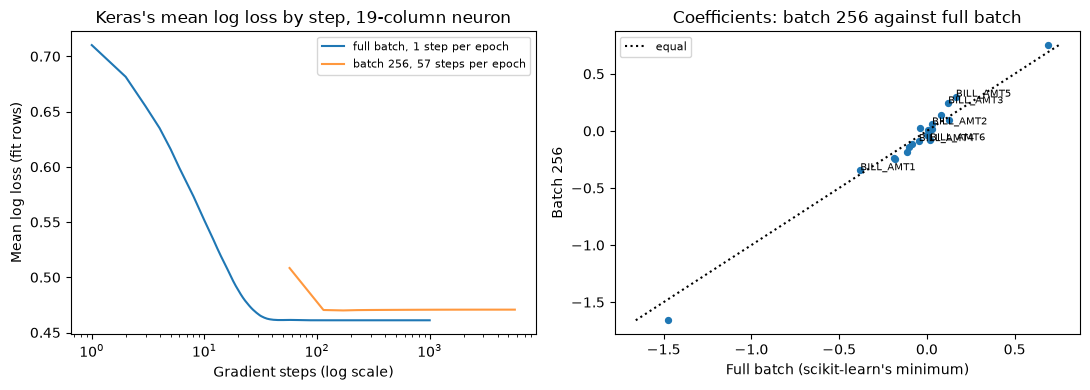

In [28]:
import matplotlib.pyplot as plt

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
# x is the number of gradient steps taken by the end of each epoch
left.plot(range(1, 1000 + 1), history_19.history["loss"], label="full batch, 1 step per epoch")
left.plot([steps_per_epoch * (e + 1) for e in range(100)], history_batch.history["loss"],
          label=f"batch 256, {steps_per_epoch} steps per epoch", alpha=0.8)
left.set_xscale("log")
left.set_title("Keras's mean log loss by step, 19-column neuron")
left.set_xlabel("Gradient steps (log scale)")
left.set_ylabel("Mean log loss (fit rows)")
left.legend(fontsize=8)

right.scatter(coefficients_19, coefficients_batch, s=18)
low, high = min(coefficients_19.min(), coefficients_batch.min()), max(coefficients_19.max(), coefficients_batch.max())
right.plot([low, high], [low, high], color="black", linestyle=":", label="equal")
for bill in bills:
    right.annotate(bill, (coefficients_19[bill], coefficients_batch[bill]), fontsize=7)
right.set_title(f"Coefficients: batch 256 against full batch")
right.set_xlabel("Full batch (scikit-learn's minimum)")
right.set_ylabel(f"Batch 256")
right.legend(fontsize=8)
plt.tight_layout()
plt.show()

* Left: the full-batch loss falls smoothly; the batch-256 loss (Keras averages it over each epoch's steps) falls faster at first, then stays above it, jittering. Right: points on the dotted line are coefficients both fits agree on; the labelled bill columns include the three weights furthest off it.

## 2.8 The Chosen Neuron on the Validation Rows

Q. Score the chosen neuron once on the validation rows, beside scikit-learn's fit on the same fit rows and Course 4's logistic regression (fitted on all 18,000 training rows with scikit-learn's default penalty, recomputed).

In [29]:
from sklearn.pipeline import Pipeline

output_valid = neuron_19.predict(A_valid, verbose=0)[:, 0]
sklearn_valid = reference_19.predict_proba(A_valid.astype("float64"))[:, 1]
# Course 4's logistic regression: scaled inside a pipeline, fitted on the 18,000 training rows
logistic = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=1000))]).fit(X_train, y_train)
proba_logistic = logistic.predict_proba(X_valid)[:, 1]
for name, output in [("neuron, 19 columns, fit rows", output_valid), ("scikit-learn, same fit rows", sklearn_valid),
                     ("Course 4 logistic regression", proba_logistic)]:
    print(f"{name}: validation ROC AUC {roc_auc_score(y_valid, output):.4f}, "
          f"average precision {average_precision_score(y_valid, output):.4f}")

neuron, 19 columns, fit rows: validation ROC AUC 0.7180, average precision 0.4945
scikit-learn, same fit rows: validation ROC AUC 0.7180, average precision 0.4945
Course 4 logistic regression: validation ROC AUC 0.7190, average precision 0.4946


**Rows.** Every network on the card file in this notebook is fitted on Course 4's 18,000 training rows (14,400 to fit and 3,600 to stop or choose) and scored on Course 4's 6,000 validation rows; Course 4's 6,000 test rows are never scored in this course.

* The neuron scores 0.7180 ROC AUC and 0.4945 average precision, scikit-learn on the same rows the same to 4 decimals. Course 4's 0.7190 and 0.4946 were fitted on all 18,000 training rows, with a small penalty: 3,600 more rows to learn from, so a slightly higher ROC AUC is no surprise. The output is the model probability of default in this file.
* This is the bar for day 3: everything a hidden layer adds has to show up beside these numbers, chosen on the stopping rows first.

## Excel Side by Side

Excel has no Keras and no network training: no `Dense` layer, no Adam, no mini-batches. What it has is enough for one neuron, because one neuron is a logistic regression and Solver fits logistic regressions. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-06) and checked against Python.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| The two-column neuron's output | `neuron_two.predict(...)` | `=1/(1+EXP(-($K$1+$K$2*B2+$K$3*D2)))` in E2, filled down | |
| Log-likelihood and its sum | `-len(y) * mean_log_loss` | `=A2*LN(E2)+(1-A2)*LN(1-E2)` in F2, filled down; `=SUM(F2:F18001)` in K4 | -8,420.2147 at Solver's answer |
| Fit the weights | `neuron_two.fit(...)` | Solver: maximise K4 by changing K1:K3, GRG Nonlinear | intercept -1.102607, weights 0.721293 and -0.020327 |
| Odds ratios | `np.exp(coefficients)` | `=EXP(K2)`, `=EXP(K3)` | 2.0571 and 0.9799 |
| Each column's mean on the fit rows | `scaler.mean_` | `=AVERAGE(fit!A2:A14401)`, filled right | equal to scikit-learn's |
| Each column's standard deviation on the fit rows | `scaler.scale_` | `=STDEV.P(fit!A2:A14401)`, filled right | equal to scikit-learn's |
| Scale a validation row | `fit_arrays(...)` | `=(A2-stats!A$2)/stats!A$3`, filled right and down | equal within 1e-6 relative |
| The 19-column neuron's output | `neuron_19.predict(A_valid)` | `=1/(1+EXP(-(stats!$B$6+SUMPRODUCT(U2:AM2,stats!$A$4:$S$4))))` | equal within 1e-6 |

**Solver is the neuron's fit.** Section 2.5 walked through it: outputs in E, log-likelihoods in F, their sum in K4, Solver changing K1:K3. Then `=EXP(K2)` beside the weight is the odds ratio, as in Course 4.

**Scaling on the fit rows only is two rows of formulas.** Paste the 14,400 fit rows on a sheet named `fit`, one column per feature. On a sheet named `stats`, row 2 is `=AVERAGE(fit!A2:A14401)` and row 3 is `=STDEV.P(fit!A2:A14401)`, filled right across the 19 columns. `STDEV.P` is the population standard deviation, the one `StandardScaler` uses (not `STDEV.S`). Only the fit rows are in those ranges: that is `fit_arrays`. On the `valid` sheet, with the 6,000 validation rows in A:S, each scaled cell is `=(A2-stats!A$2)/stats!A$3`: the validation value minus the **fit rows'** mean, over the **fit rows'** standard deviation. The `$` before the row numbers keeps every row pointing at rows 2 and 3 of `stats`.

**The neuron's output is one SUMPRODUCT.** Paste the 19 fitted weights in row 4 of `stats` and the intercept in B6. Then `=1/(1+EXP(-(stats!$B$6+SUMPRODUCT(U2:AM2,stats!$A$4:$S$4))))` is the intercept plus the sum of each scaled input times its weight, through the sigmoid: `predict`, row by row.

Q. Do Excel's numbers equal Python's?

In [30]:
# Excel's numbers, from the course's Excel check, beside Python's for the same rows
excel_means = np.array([166552.77777777778, -0.014722222222222222, -0.14381944444444444, -0.17083333333333334, -0.22208333333333333, -0.2667361111111111, -0.2906944444444444, 50435.07763888889, 48276.31715277778, 46332.84354166667, 42763.88520833333, 39861.0725, 38278.8775, 5581.020972222223, 5796.89375, 5188.418055555556, 4752.257569444444, 4661.728541666666, 5248.866875])
excel_sds = np.array([128867.5245404087, 1.1144529951483202, 1.187292377479917, 1.1926205389812805, 1.1676715166661098, 1.1310168297826266, 1.1502159536231167, 72308.88328607331, 69861.16358520213, 68101.05621071246, 63995.448588938976, 60450.21178463286, 58866.07680629698, 17190.625549012628, 20364.22356430962, 17791.040563072645, 15437.032817981883, 14439.260268765765, 18284.0981862538])
excel_outputs = np.array([0.2502423226156515, 0.1432986328782311, 0.05443614895170863, 0.10119933453331255, 0.10141977451567596])
checks = {
    "Solver's coefficients, within 1e-4 of the neuron's": bool(np.abs(solver - coefficients_two).max() < 1e-4),
    "EXP of Solver's weights, within 1e-12 of numpy's exp": bool(np.abs(np.array([2.057090623576002, 0.979877847489704]) - np.exp(solver.iloc[1:].to_numpy())).max() < 1e-12),
    "AVERAGE of the fit rows, relative gap below 1e-12": bool(np.all(np.abs(excel_means - scaler.mean_) <= 1e-12 * np.abs(scaler.mean_))),
    "STDEV.P of the fit rows, relative gap below 1e-12": bool(np.all(np.abs(excel_sds - scaler.scale_) <= 1e-12 * scaler.scale_)),
    "SUMPRODUCT outputs (first five rows), within 1e-6 of predict": bool(np.abs(excel_outputs - output_valid[:5]).max() < 1e-6),
}
for label, result in checks.items():
    print(f"{label}: {result}")

Solver's coefficients, within 1e-4 of the neuron's: True
EXP of Solver's weights, within 1e-12 of numpy's exp: True
AVERAGE of the fit rows, relative gap below 1e-12: True
STDEV.P of the fit rows, relative gap below 1e-12: True
SUMPRODUCT outputs (first five rows), within 1e-6 of predict: True


* Every check holds. The cell shows the first five rows of the output column; the course's Excel check compared all 6,000 validation rows, and the largest gap from `predict` was below 1e-6 (Excel works in float64 from the raw values, Keras in float32).

## Save the Day with Git

Today's work folder is new, so it starts its own repository: the same start and the same `.gitignore` as day 1, the modules committed as they stand at the end of today, then day 1's experiment log, then today's row and a look at exactly what it changed.

Q. Start the repository and commit the code.

In [31]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [32]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course6_02_6cicsqzt and nowhere else


In [33]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
*.keras

Writing .gitignore


In [34]:
!git -C "{work}" add .gitignore mlkit.py ensemblekit.py netkit.py test_netkit.py
!git -C "{work}" commit -q -m "netkit: fit_arrays and neuron_coefficients, 10 tests"
!git -C "{work}" log --oneline

e8ef3ec netkit: fit_arrays and neuron_coefficients, 10 tests


Q. Write day 1's experiment log as day 1 committed it, and commit it.

In [35]:
# day 1's log as day 1 wrote it: 4 decimals and LF line endings, like every results.csv in the course
day1_log = """model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
course4_logistic_regression,validation,0.7190,0.4946,0.5000,0.8123,0.7248,0.2442,0.3653
pay_0_neuron_by_hand,validation,0.6834,0.4241,0.5000,0.8160,0.6831,0.3135,0.4298
"""
(work / "results.csv").write_text(day1_log, encoding="utf-8", newline="\n")
print(day1_log)

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
course4_logistic_regression,validation,0.7190,0.4946,0.5000,0.8123,0.7248,0.2442,0.3653
pay_0_neuron_by_hand,validation,0.6834,0.4241,0.5000,0.8160,0.6831,0.3135,0.4298



In [36]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log as day 1 left it"

Q. Add the 19-column neuron's validation row, at threshold 0.5 as on day 1, and ask Git what changed.

In [37]:
# day 1's log, plus one row for today's chosen neuron
results = pd.read_csv("results.csv")
metrics = mlkit.classification_metrics(y_valid, (output_valid >= 0.5).astype(int))
row = {"model": "neuron_19_columns", "rows": "validation", "roc_auc": roc_auc_score(y_valid, output_valid),
       "average_precision": average_precision_score(y_valid, output_valid), "threshold": 0.5, **metrics}
results = pd.concat([results, pd.DataFrame([row])], ignore_index=True)
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print(f"results.csv: {len(results)} rows")

results.csv: 3 rows


In [38]:
# lines starting with + were added, lines starting with - removed
!git -C "{work}" diff results.csv

diff --git a/results.csv b/results.csv
index 68f3907..128cb96 100644
--- a/results.csv
+++ b/results.csv
@@ -1,3 +1,4 @@
 model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
 course4_logistic_regression,validation,0.7190,0.4946,0.5000,0.8123,0.7248,0.2442,0.3653
 pay_0_neuron_by_hand,validation,0.6834,0.4241,0.5000,0.8160,0.6831,0.3135,0.4298
+neuron_19_columns,validation,0.7180,0.4945,0.5000,0.8115,0.7130,0.2472,0.3671


* Under the header lines (`---` and `+++` name the old and new file), one line starts with `+`: the new row. No row starts with `-`, so the header row and the two rows day 1 wrote are unchanged to the fourth decimal. Writing every number with 4 decimals and LF line endings is what makes a diff this clean.
* The neuron's line: `neuron_19_columns,validation,0.7180,0.4945,0.5000,0.8115,0.7130,0.2472,0.3671`.

In [39]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the 19-column neuron fitted in Keras, validation metrics"
!git -C "{work}" log --oneline

ee2c621 Experiment log: the 19-column neuron fitted in Keras, validation metrics
35664c9 Experiment log as day 1 left it
e8ef3ec netkit: fit_arrays and neuron_coefficients, 10 tests


## Bring It Home

Add today's two functions to your own `netkit.py` in `my_bondmath`. Open a PowerShell terminal in VS Code.

**Step 1.** Go to your folder and activate the course's environment.

```powershell
Set-Location "$HOME\projects\my_bondmath"
& "$HOME\projects\python-fixed-income\.venv\Scripts\Activate.ps1"
code netkit.py
code test_netkit.py
```

**Step 2.** Paste the code of the two `%%writefile -a netkit.py` cells (sections 2.2 and 2.4), without their first lines, at the end of `netkit.py`; do the same for the two `test_netkit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_netkit.py
```

The last line says `10 passed`.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add netkit.py test_netkit.py
git commit -m "netkit: fit_arrays and neuron_coefficients, 10 tests"
git log --oneline -3
```

`git diff --stat` shows two files changed and only insertions: today added code and changed nothing day 1 wrote.

## You Can Now

* Say what a Keras `Dense` layer of one unit with a sigmoid computes, and read its kernel and bias.
* Carve fit and stopping rows with Course 5's `early_stopping_rows`, and scale for a network with `fit_arrays`, fitted on the fit rows only.
* Say what each argument of `compile` and `fit` does.
* Fit one neuron in Keras and show with `neuron_coefficients` that it is scikit-learn's logistic regression, odds ratios and all.
* Fit the same model with Solver, and scale and score it with `AVERAGE`, `STDEV.P`, and `SUMPRODUCT`.
* Explain why near-copy columns make single weights hard to read, and see a mini-batch fit stop short.
* Choose between two fits on the stopping rows, and report the choice once on the validation rows.

Next, day 3: hidden layers and activations, the first network that is more than a logistic regression.

## Exercises

The exercises use Course 4's 18,000 card training rows and the fit and stopping rows carved from them; the test rows are closed, the four person columns are not features, and every answer describes this file. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the card rows, carves the fit and stopping rows, builds the two columns of section 2.4, and defines `check`, a small function that marks your answers.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Course 4's training and validation rows of the card file, and Course 5's fit and stopping rows
card = pd.read_csv("credit_card_default.csv")
X_train, X_valid, y_train, y_valid = ensemblekit.course4_card_rows(card)
X_fit, X_stop, y_fit, y_stop = ensemblekit.early_stopping_rows(X_train, y_train)

# section 2.4's two columns on the training rows, unscaled
two_train = pd.DataFrame({"PAY_0": X_train["PAY_0"], "LIMIT_BAL_10k": X_train["LIMIT_BAL"] / 10_000})


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Fit section 2.4's two-column neuron again, unscaled, full batch, 300 epochs on the training rows, but with plain gradient descent, `keras.optimizers.SGD(learning_rate=0.5)`, in place of Adam. Seed first. Store Keras's mean log loss in the last epoch in **ex1_last_loss**. Does it reach section 2.4's 0.4678? Why not?

In [41]:
ex1_last_loss = ...

In [42]:
check("Exercise 1 the last loss with plain gradient descent", ex1_last_loss, 1.8765451908111572)

Exercise 1 the last loss with plain gradient descent: not attempted yet


### Exercise 2

Q. Fit scikit-learn's logistic regression on the same two columns with its **default** penalty (`LogisticRegression(max_iter=1000)`, which means `C=1.0`), and the unpenalised one (`C=np.inf, tol=1e-8, max_iter=1000`). Store the largest absolute difference between their intercepts and weights in **ex2_largest_gap**. Is it inside the 1e-4 this notebook used to say "equal"?

In [43]:
ex2_largest_gap = ...

In [44]:
check("Exercise 2 the largest gap from the penalty", ex2_largest_gap, 0.0002664965070009462)

Exercise 2 the largest gap from the penalty: not attempted yet


### Exercise 3

Q. Add a function to your module. `odds_ratio_table(coefficients)` takes a Series as `neuron_coefficients` returns it (intercept first) and returns a DataFrame indexed by the columns, without the intercept, with columns `weight` and `odds_ratio` (e to the weight); it refuses a Series whose first entry is not named `intercept` with `ValueError`. Write the docstring first. Then add `test_odds_ratio_table_hand`, which checks on the hand Series `[0.25, 0.75, -0.5]` (indexed `intercept`, `PAY_0`, `LIMIT_BAL`) that the table has no intercept row, that the odds ratios are e to 0.75 and e to -0.5, and that a Series without the intercept raises. The test file does not import pandas yet: add `import pandas as pd` above your test. Run pytest, reload the module, and store the odds ratio of `LIMIT_BAL_10k` from scikit-learn's unpenalised two-column fit (put its intercept and weights in a Series indexed `intercept`, `PAY_0`, `LIMIT_BAL_10k`) in **ex3_odds_limit**.

Write the function in the cell that starts with `%%writefile -a netkit.py` and the test in the one that starts with `%%writefile -a test_netkit.py`, and run each of those cells once.

In [45]:
%%writefile -a netkit.py


# Exercise 3: write odds_ratio_table(coefficients) below this line

Appending to netkit.py


In [46]:
%%writefile -a test_netkit.py


# Exercise 3: write test_odds_ratio_table_hand() below this line

Appending to test_netkit.py


In [47]:
# run pytest, reload the module, then use your function
ex3_odds_limit = ...

In [48]:
check("Exercise 3 the odds ratio of the limit", ex3_odds_limit, 0.9798778416605826)

Exercise 3 the odds ratio of the limit: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that scales the card rows for a network, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Scale the card rows for a network.

    Inputs: X_fit, the rows the network is fitted on; X_stop, the stopping rows; X_valid, the validation rows.
    Output: (scaler, A_fit, A_stop, A_valid): a StandardScaler fitted on the fit rows only, and float32 arrays of
    the three sets of rows scaled by it.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns a scaler and three float32 arrays of the right shapes, and contains one bug.

In [49]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def scale_for_network(X_fit, X_stop, X_valid):
    """Scale the card rows for a network.

    Inputs: X_fit, the rows the network is fitted on; X_stop, the stopping rows; X_valid, the validation rows.
    Output: (scaler, A_fit, A_stop, A_valid): a StandardScaler fitted on the fit rows only, and float32 arrays of
    the three sets of rows scaled by it.
    """
    # more rows give the scaler steadier means and standard deviations
    scaler = StandardScaler().fit(pd.concat([X_fit, X_valid]))
    return (scaler, *(scaler.transform(rows).astype("float32") for rows in (X_fit, X_stop, X_valid)))

Q. Before you run the next cell: the scaled fit rows should have every column's mean at exactly 0. How far off 0 do you expect them to be with this function?

In [50]:
ai_scaler, ai_fit, ai_stop, ai_valid = scale_for_network(X_fit, X_stop, X_valid)
print(f"arrays: {ai_fit.shape}, {ai_stop.shape}, {ai_valid.shape}, dtype {ai_fit.dtype}")
# how far the scaled fit columns' means are from 0, in standard deviations
print(f"largest mean of a scaled fit-row column: {np.abs(ai_fit.astype('float64').mean(axis=0)).max():.4f}")

arrays: (14400, 19), (3600, 19), (6000, 19), dtype float32
largest mean of a scaled fit-row column: 0.0085


Q. Test the function against its docstring before you trust it: the scaler's means and standard deviations must be the fit rows' own.

In [51]:
# the test, written from the docstring before the code is trusted
ai_scaler, ai_fit, ai_stop, ai_valid = scale_for_network(X_fit, X_stop, X_valid)
# the docstring's promise: the scaler's statistics are the fit rows' alone
fit_means, fit_sds = X_fit.mean().to_numpy(), X_fit.std(ddof=0).to_numpy()
limit = X_fit.columns.get_loc("LIMIT_BAL")
assert np.allclose(ai_scaler.mean_, fit_means, rtol=1e-9, atol=0), \
    f"LIMIT_BAL mean used {ai_scaler.mean_[limit]:,.2f}; the fit rows' mean is {fit_means[limit]:,.2f}"
assert np.allclose(ai_scaler.scale_, fit_sds, rtol=1e-9, atol=0), "the standard deviations are not the fit rows'"
print(f"scale_for_network fitted on the fit rows only: LIMIT_BAL mean {ai_scaler.mean_[limit]:,.2f}")

AssertionError: LIMIT_BAL mean used 166,784.12; the fit rows' mean is 166,552.78

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the `LIMIT_BAL` mean the fixed function's scaler uses, `scale_for_network(X_fit, X_stop, X_valid)[0].mean_[0]`, in **ex4_limit_mean**.

In [52]:
# fix the function above and run the test again, then store the answer
ex4_limit_mean = ...

In [53]:
check("Exercise 4 the fixed scaler's LIMIT_BAL mean", ex4_limit_mean, 166552.77777777778)

Exercise 4 the fixed scaler's LIMIT_BAL mean: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```